In [1]:
# Preamble
import networkx as nx
from itertools import permutations
import matplotlib.pyplot as plt
import random
import io, contextlib
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
import heapq
from itertools import product
from time import process_time
import time

# MT3510 Pure Team Project


## Introduction

## Coding Tasks Part 1: Synchronization

## What is Synchronization?

A deterministic finite automaton (DFA) is said to be *synchronizing* if there exists a word $w$ over its alphabet such that, regardless of which state the automaton starts in, applying $w$ always leads to the same state. Such a word is called a *reset word* or *synchronizing word*. Intuitively, a reset word eliminates all  ncertainty about the current state of the automaton, after applying it, the state is known with certainty regardless of the automaton's history.

The practical motivation is straightforward. In any system modelled as a finite automaton whose current state is unknown, a reset word provides a way to recover a known state without needing to observe or control the starting configuration. This has applications in robotics, where a sequence of operations may need to bring a mechanism to a known position, and in coding theory, where synchronizing words are used to recover from errors in sequence transmission.

Not all DFAs are synchronizing. If every letter in the alphabet induces a permutation on the state set, the transition monoid is a permutation group and no two states can ever be merged by any word, making synchronization impossible. For DFAs that are synchronizing, the central computational questions are whether a reset word exists, how to find one, and how short the shortest such word can be. These questions are the focus of Part 1.

## Permutation Checker Function

A key structural property of a DFA determines whether a synchronizing word can exist at all: if every letter in $\Sigma$ induces a permutation on $Q$, the transition monoid is a permutation group, and no reset word can exist. Detecting this early avoids unnecessary computation.

A transformation $t$ on state set $Q$ is a permutation if and only if it is injective - that is, no two states map to the same image. `is_permutation` checks this by collecting the images of all states under $t$ and comparing the number of distinct images to $|Q|$. If they are equal, every state maps to a unique image and $t$ is a permutation; if any two states share an image the count is smaller and $t$ is not.

In [2]:
# Function to check if a given monoid is made entirely of permuations, implemented across all parts of the code
def is_permutation(t, Q):
    images = [t[q] for q in Q]
    return len(set(images)) == len(Q)

## Complexity Analysis

### Permutation Pre-Check

For each letter $a \in \Sigma$, we check whether the induced transformation
$\tau_a : Q \to Q$ is a permutation, i.e. whether it is injective. This requires
checking that no two states share the same image under $\tau_a$, which can be done
by inserting all images into a set and comparing its size to $|Q|$:

$$|\{\tau(q, a) : q \in Q\}| = |Q|$$

This takes $O(|Q|)$ time per letter, and since there are $|\Sigma|$ letters the
total cost is $O(|\Sigma| \cdot |Q|)$. Since $|\Sigma| \ll |Q|$ by assumption,
this is effectively $O(|Q|)$ in practice.

In [3]:
A = {"Q": tuple(range(2)),
    "Sigma": {"a", "b"},
    "tau": {"a":(1, 2, 2),"b":(0, 0, 1)},
    "q_s": 0,
    "F": {0}}


B = {"Q": tuple(range(5)),
    "Sigma": {"a", "b"},
    "tau": {"a": (1, 2, 3, 4, 0), "b": (0, 1, 2, 3, 0),},
    "q_s": 0,
    "F": {0}}

C = {"Q": tuple(range(2)),
    "Sigma": {"a", "b"},
    "tau": {"a": (1, 0),"b": (0, 0),},
    "q_s": 0,
    "F": {0}}

P = {"Q": tuple(range(3)),
    "Sigma": {"a"},
    "tau": {"a": (1, 2, 0),},
    "q_s": 0,
    "F": {0}}


## Q1(A) - BFS Synchronization via Transition Monoid
*(Caelan and Alex)*

**Algorithm Design**

The synchronization check uses a breadth-first search over the transition monoid.Each letter $a \in \Sigma$ induces a transformation $\tau_a : Q \to Q$, and composing these corresponds to reading sequences of letters. The DFA is synchronizing if and only if the monoid contains a *constant transformation* - one that maps every state to a single state. Each transformation is represented as a tuple of images over $Q$ in sorted state order, so $\tau_a$ becomes `tuple(tau[(q, a)] for q in states)`. This fixed ordering means that two transformations with the same action on $Q$ always produce identical tuples, making the `seen` set deduplication correct. On each step, the current transformation $f$ is composed with each generator $\tau_a$ via
`compose(f, t_a)`, and any composition not yet in `seen` is enqueued. BFS explores level by level, guaranteeing that if a constant transformation exists at depth $k$
it is found at depth $k$, naturally yielding the shortest reset word. If the queue is exhausted without finding one, `False` is returned.

In [4]:
def synchronizing_bfs(A):
    """
    Determines whether a DFA is synchronizing by performing a BFS over the
    transition monoid, searching for a constant transformation.

    Returns the constant transformation as a tuple if the DFA is synchronizing,
    or False if it is not.
    """
    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]

    # Early exit: if every letter induces a permutation on Q, the transition
    # monoid is a permutation group and no constant transformation can exist
    if all(is_permutation(tau[a], Q) for a in Sigma):
            return False

    # Build the initial set of generator transformations, one per letter,
    # each represented as a tuple of images indexed by sorted state order
    values = [tuple(tau[a][q] for q in Q) for a in Sigma]
    queue = values[:]                            # Working queue for BFS
    seen = set(queue)                            # Track visited transformations

    while queue:
        f = queue.pop(0)                         # Dequeue next transformation

        if len(set(f)) == 1:                     # Constant transformation found
            return f

        for t_a in values:                       # Compose with each generator
            ft_a = compose(f, t_a)
            if ft_a not in seen:                 # If unseen, add to queue
                seen.add(ft_a)
                queue.append(ft_a)

    return False                                 # No constant transformation found

**Code Development**

Two bugs were identified and fixed during development. The first arose from composing transformations while iterating over the frontier without a copy — elements were consumed mid-loop, causing valid reset words to be missed. This was fixed by maintaining a separate copy of the frontier during composition. The second bug cause reset words of length one to be overlooked: the constant-transformation check was written as `len(f) == 1`, which tests the length of the tuple rather than the number of distinct images. Replacing this with `len(set(f)) == 1` correctly identifies any transformation whose image is a single state, regardless of how many states map to it.

### Demonstration 

The algorithm was tested on DFAs $B$, $C$, and $P$ to verify correctness across synchronizing and non-synchronizing cases. For each DFA the BFS is run with
`verbose=True`, printing each newly discovered image as it is first encountered. The sequence of images shows how the state set contracts under successive letters,  a synchronizing DFA produces a chain of strictly shrinking images terminating in a singleton, while a non-synchronizing DFA exhausts all reachable images without one ever reaching size 1.

## Complexity Analysis

A transformation on $Q$ is a function $f : Q \to Q$. The total number of such
functions is $|Q|^{|Q|}$, so the transition monoid contains at most $|Q|^{|Q|}$
distinct elements.
Each transformation is represented as a tuple of length $|Q|$, and composing two
transformations $f$ and $g$ requires computing $f(g(q))$ for each $q \in Q$,
taking $O(|Q|)$ time. Since each of the at most $|Q|^{|Q|}$ transformations is
processed exactly once (enforced by the seen set), the total complexity is:
$$O\!\left(|Q|^{|Q|} \cdot |Q|\right) = O\!\left(|Q|^{|Q|+1}\right)$$
This is significantly worse than the image BFS bound above, which motivates
using the image-based approach for larger DFAs.

### Analysis of Results

The algorithm performs as expected across all test cases. Because BFS explores all images reachable by words of length $k$ before any image reachable by a word
of length $k+1$, the first singleton found is guaranteed to correspond to a shortest reset word. Non-synchronizing permutation-group DFAs are caught by the
early exit in $O(|\Sigma| \cdot |Q|)$ time before any BFS is performed.

DFA $B$ (the Černý automaton $C_5$) and $C$ (the Černý automaton $C_2$) are correctly identified as synchronizing. DFA $P$, whose single letter induces a cyclic permutation on $Q$,
triggers the early exit immediately since every letter is a permutation and no image can ever shrink.


## 1 (B) BFS Synchronization via Image
*(Alfie and Megu)*

### Description of Implementation

Question 1(b) determines whether a DFA is synchronizing by searching for an image of size 1 using breadth-first search over subsets of the state set $Q$. A DFA is
synchronizing if and only if there exists a word that maps the entire state set to a single state, so the algorithm searches for such an image directly.

The BFS begins with the full state set $Q$, represented as a sorted tuple. For each image dequeued and each letter $a \in \Sigma$, the transition function $\tau$ is
applied to every state in the current image to produce a new image. If this image has not been seen before it is added to the queue; if its size is 1 a singleton has
been found and the DFA is synchronizing. If the queue is exhausted without finding a singleton, no reset word exists and the DFA is not synchronizing.

Subsets are stored as sorted tuples rather than sets so that the same collection of states always produces the same key regardless of the order they were visited, which
is necessary for the visited-set deduplication to work correctly. A `deque` with `popleft()` is used in place of a plain list to ensure each dequeue operation runs
in $O(1)$ rather than $O(n)$.

In [5]:
from collections import deque

def synchronizing_bfs_image(A, verbose=False):
    """
    Determines whether a DFA is synchronizing by performing a BFS over images
    of the state set, searching for an image of size 1 (a singleton).

    Returns True if the DFA is synchronizing, False otherwise.
    The optional verbose flag prints progress information during the search.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]

    # Early exit: if every letter induces a permutation on Q, the transition
    # monoid is a permutation group and no singleton image can exist
    if all(is_permutation(tau[a], Q) for a in Sigma):
        if verbose:
            print("All letters induce permutations - not synchronizing.")
        return False

    queue = deque([Q])                               # Initialise with full state set
    seen = {Q}                                       # Track visited images

    while queue:
        current_Q = queue.popleft()                  # O(1) dequeue
        if len(current_Q) == 1:                      # Singleton found - synchronizing
            if verbose:
                print("Synchronizing state found:", current_Q)
            return True
        for a in Sigma:
            # Apply letter a to every state in the current image
            new_Q = tuple(sorted({tau[a][q] for q in current_Q}))
            if new_Q not in seen:
                if verbose:
                    print(f"Visiting image {new_Q} for the first time")
                seen.add(new_Q)
                queue.append(new_Q)

    return False                                     # No singleton found - not synchronizing

### Code Development

Several implementation issues arose during development and were addressed to improve correctness and efficiency.

Firstly, subsets of states were initially represented as sets, which caused errors when attempting to store them in the `seen`. This was resolved by converting each subset into a `sorted` tuple, ensuring that making it constant and consistently represented.

Secondly, consistency in representation was improved by always sorting the resulting subsets before converting them into tuples. This avoids duplicate representations of the same subset and ensures correct behaviour of the `seen` check.

Moreover, the use of `deque` instead of `list` significantly improves efficiency, as it allows constant-time dequeue operations while preserving BFS order.

### Demonstration & Visualization
The algorithm was tested on several DFAs to observe how the subsets evolve during the BFS.
At each step, newly discovered subsets are recorded when first visited. The sequence of subsets reflects how the image of $Q$ evolves under different words. If at any point the size of the subset decreases to 1, a synchronizing state has been found.
For synchronizing DFAs, the algorithm successfully identified a singleton subset, confirming the existence of a synchronizing word. For non-synchronizing DFAs, the algorithm explored all reachable subsets without finding such a singleton.

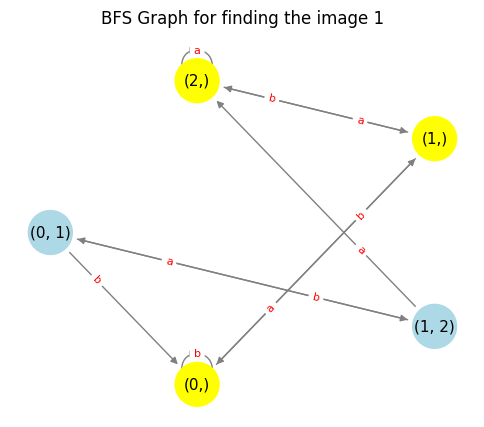

In [6]:
def visualize_bfs_image(A, verbose=False):
    Q = tuple(sorted(A["Q"]))  # Sort for consistent tuple keys 
    tau = A["tau"]
    Sigma = A["Sigma"]

    D = nx.MultiDiGraph() # Use MultiDiGraph to draw (code based on NetworkX Developers (n.d.) example)
    queue = deque([Q])  # Initialise with full state set as starting image
    seen = {Q}          # Tracks visited images to avoid revisiting

    while queue:
        current_Q = queue.popleft()  # O(1) removal from front of deque
        
        for a in Sigma:
            t_a = tau[a]
            # Apply letter a to every state in the current image
            new_Q = tuple(sorted({t_a[q] for q in current_Q}))

            D.add_edge(current_Q, new_Q, label=a)
            
            if new_Q not in seen:
                seen.add(new_Q)
                queue.append(new_Q)
                
    return D,Q

def plot_bfs_graph(A):
    D, start = visualize_bfs_image(A)
    pos = nx.shell_layout(D) 
    
    plt.figure(figsize=(6,5))
    
    # Plot nodes with different colors 
    # Code based on NetworkX Developers (n.d.) example
    # Yellow node = the image size is 1
    colors = ["yellow" if len(n) == 1 else "lightblue" for n in D.nodes()]
    nx.draw_networkx_nodes(D, pos, node_size=1000, node_color=colors)
   
    nx.draw_networkx_labels(D, pos, font_size=11)
    nx.draw_networkx_edges(D, pos, edge_color="grey",arrows=True, min_source_margin=20, min_target_margin=20)

    labels = {(u,v,k): d["label"] for u,v,k,d in D.edges(keys=True, data=True)}
    nx.draw_networkx_edge_labels(D, 
                                 pos, 
                                 edge_labels=labels, 
                                 label_pos=0.3,
                                 font_color="red",
                                 font_size=8)

    # Plot the graph with a title 
    plt.title("BFS Graph for finding the image 1")
    plt.axis("off")
    plt.show()

plot_bfs_graph(A)

### Analysis of Results

The results are consistent with the mathematical guarantee that a DFA is
synchronizing if and only if there exists a word that maps the entire state set
to a single state — equivalently, a word under which the image of $Q$ contracts
to a singleton. The BFS graph produced by `plot_bfs_graph` makes this visible
directly: each node is a reachable image tuple, each edge is labelled with the
letter that produced it, and the unique yellow node is the singleton found by
the search. The existence of a path from the root node $Q$ to the yellow node
is precisely the certificate that a synchronizing word exists, and the sequence
of edge labels along that path is the reset word itself.

The graph also illustrates why BFS finds a *shortest* reset word. Because BFS
explores all images reachable by words of length $k$ before any image reachable
by a word of length $k+1$, the yellow node is reached via a shortest path from
$Q$ — any other route to the singleton would be at least as long. This is
visible in the graph structure: the yellow node appears at the shallowest depth
at which it is reachable, with no shorter path from the root.

The `seen` set prevents any image being enqueued more than once, so the graph
contains no redundant nodes and every edge represents a genuinely new image
encountered during the search. For non-synchronizing DFAs the graph would
contain no yellow node at all, and the BFS would terminate having exhausted
all reachable images without finding a singleton.

The worst-case complexity is $O(2^{|Q|} \cdot |Q| \cdot |\Sigma|)$, since
there are at most $2^{|Q|}$ reachable images and each requires
$O(|Q| \cdot |\Sigma|)$ work to expand. In practice the search terminates
well before exhausting all $2^{|Q|}$ subsets since a singleton is typically
found early, consistent with the empirical timing of approximately $45.7\mu s$
observed via `%timeit`. This is substantially more efficient than the monoid
BFS from Part (a), whose worst-case is $O(|Q|^{|Q|+1})$, and provides a
natural baseline for comparison with the pair graph method in Part (c).

## 1(B) Extension: Replacing the Queue with a Priority Queue

_(Alfie)_

## Description of Implementation

The standard BFS in 1(b) explores images in order of the word length used to reach them, treating all images of the same depth equally regardless of their size. This
raises a natural question: if we always prioritise smaller images, can we reach a singleton faster? The priority queue variant investigates this by replacing the
`deque` with a min-heap, so that the smallest currently known image is always expanded next rather than the oldest.

The algorithm begins by initialising the heap with the full state set $Q$, wrapped as `(len(Q), Q)` so that heap ordering is determined by image size rather than
content. This wrapping is deliberate, Python's `heapq` is a min-heap that sorts on the first element of each tuple, so without the size prefix the heap would sort
lexicographically by state label, which has no mathematical meaning in this context. On each iteration, the smallest image is popped from the heap and checked for
singleton status, returning `True` immediately if found. For each letter $a \in \Sigma$, the image $T' = \{\tau(q, a) : q \in T\}$ is computed as a sorted tuple —
sorted to ensure that the same set of states always produces the same key regardless of the order they were visited, which is necessary for the `seen` check to work
correctly. If $T'$ has not been seen before it is added to `seen` and pushed onto the heap as `(len(T'), T')`, again wrapping with its size so the heap continues to
prioritise by image size at every subsequent step. If the heap is exhausted without finding a singleton, the function returns `False`.

The tradeoff explored here is whether the more directed search strategy justifies the higher per-operation cost of heap operations compared to a plain `deque`, and
whether prioritising by image size produces shorter reset words, longer ones, or none at all compared to standard BFS.

In [7]:
import heapq

def synchronizing_pq_image(A):
    Q = tuple(sorted(A["Q"]))
    tau = A["tau"]
    Sigma = A["Sigma"]

    if all(is_permutation(tau[a], Q) for a in Sigma):
      if verbose:
          print("All letters induce permutations - not synchronizing.")
      return False

    # Priority queue entries: (image_size, image_tuple)
    # heapq is a min-heap so smallest image size is always explored first
    pq = [(len(Q), Q)]
    seen = {Q}

    while pq:
        _, current_Q = heapq.heappop(pq)

        if len(current_Q) == 1:
            return True

        for a in Sigma:
            t_a = tau[a]
            new_Q = tuple(sorted({t_a[q] for q in current_Q}))
            if new_Q not in seen:
                seen.add(new_Q)
                heapq.heappush(pq, (len(new_Q), new_Q))

    return False

## Code Development

The key implementation decision is how to structure heap entries. Python's `heapq` is a min-heap sorting on the first element of each tuple, so wrapping each image as `(len(new_Q), new_Q)` ensures the smallest image is always
popped first.

**Bug, pushing the image tuple directly:** An initial version pushed `new_Q` into the heap without a size prefix:

```python
heapq.heappush(pq, new_Q)                # buggy
heapq.heappush(pq, (len(new_Q), new_Q))  # fixed
```

This causes `heapq` to sort lexicographically by tuple contents rather than by image size, so `(0, 1)` would be prioritised over `(2, 3, 4)` not because it is smaller but because `0 < 2` numerically. The function still returns the correct boolean result, making this bug difficult to detect since it only affects exploration order rather than correctness. When two images share the same size, `heapq` breaks ties by comparing the image tuples directly. Since these are tuples of integers this is well defined in Python, but the tie breaking order is lexicographic rather than mathematically meaningful.


## Demonstration & Visualisaton

BFS time (avg over 1000 runs): 92.08μs
PQ  time (avg over 1000 runs): 76.50μs
PQ/BFS ratio: 0.83x (faster)


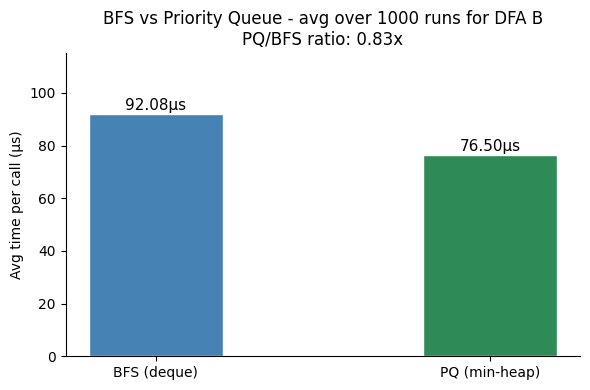

BFS time (avg over 1000 runs): 8.39μs
PQ  time (avg over 1000 runs): 8.88μs
PQ/BFS ratio: 1.06x (slower)


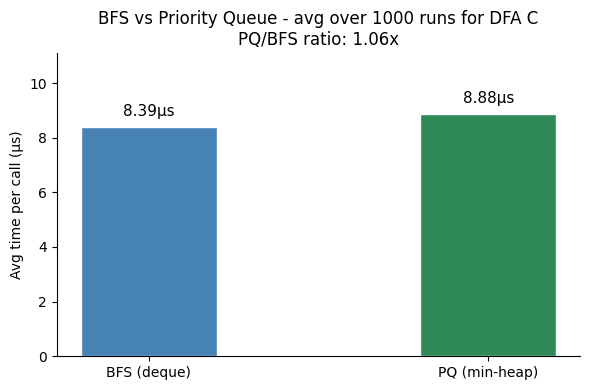

In [8]:
def compare_bfs_pq(A, name, runs=1000):
    """
    Compares the average runtime of BFS and priority queue synchronization
    checks over a given number of runs, and plots the results as a bar chart.

    The optional runs parameter controls how many iterations are averaged.
    A PQ/BFS ratio below 1 means PQ is faster, above 1 means BFS is faster.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]                      # Unpack the 5-tuple

    # Time BFS over 'runs' iterations, suppressing print output during timing
    with contextlib.redirect_stdout(io.StringIO()):
        start = time.perf_counter()
        for _ in range(runs):
            synchronizing_bfs_image(A)
        bfs_time = (time.perf_counter() - start) / runs

    # Same for PQ
    with contextlib.redirect_stdout(io.StringIO()):
        start = time.perf_counter()
        for _ in range(runs):
            synchronizing_pq_image(A)
        pq_time = (time.perf_counter() - start) / runs

    # Convert to microseconds for readability
    bfs_us = bfs_time * 1e6
    pq_us  = pq_time  * 1e6
    ratio  = pq_time / bfs_time                      # Ratio < 1 means PQ is faster

    print(f"BFS time (avg over {runs} runs): {bfs_us:.2f}\u03bcs")
    print(f"PQ  time (avg over {runs} runs): {pq_us:.2f}\u03bcs")
    print(f"PQ/BFS ratio: {ratio:.2f}x ({'faster' if ratio < 1 else 'slower'})")

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(['BFS (deque)', 'PQ (min-heap)'], [bfs_us, pq_us],
                  color=['steelblue', 'seagreen'], width=0.4, edgecolor='white')

    for bar, val in zip(bars, [bfs_us, pq_us]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.2f}\u03bcs', ha='center', va='bottom', fontsize=11)

    ax.set_ylabel('Avg time per call (\u03bcs)')
    ax.set_title(f'BFS vs Priority Queue - avg over {runs} runs for DFA {name}\n'
                 f'PQ/BFS ratio: {ratio:.2f}x')
    ax.set_ylim(0, max(bfs_us, pq_us) * 1.25)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

# Runtime comparison
compare_bfs_pq(B, "B")
compare_bfs_pq(C, "C")

## Complexity Analysis

The state of the BFS is a subset $S \subseteq Q$, representing the current image
of the state set under some word $w$. The number of distinct subsets of $Q$ is
$2^{|Q|}$, so there are at most $2^{|Q|}$ nodes in the search space.

For each node $S$, we apply every letter $a \in \Sigma$ to obtain the next image:

$$S \xrightarrow{a} \{\tau(q, a) : q \in S\}$$

Computing this image requires iterating over all $q \in S$, which takes $O(|Q|)$
time in the worst case. Since we do this for each of the $|\Sigma|$ letters, the
work per node is $O(|Q| \cdot |\Sigma|)$.

Combined with the at most $2^{|Q|}$ nodes, the total complexity is:

$$O\!\left(2^{|Q|} \cdot |Q| \cdot |\Sigma|\right)$$

In practice the search terminates well before exhausting all $2^{|Q|}$ subsets,
since a singleton image is typically found early and the `visited` set prevents
any subset being processed more than once.

## Analysis of Output

The priority queue changes the order of exploration but not the correctness, both methods correctly identify whether a DFA is synchronizing. Standard BFS explores images in order of  the word length used to reach them, guaranteeing that the first singleton found corresponds to a shortest reset word. The priority queue instead always expands the smallest currently known image, sacrificing the minimality guarantee in exchange for potentially reaching a singleton having visited fewer nodes.

This comes at a cost. Each `heappush` and `heappop` operation costs $O(\log n)$, compared to $O(1)$ for `deque.append` and `deque.popleft()`. Whether this overhead is worth paying depends entirely on the structure of the DFA being tested, and the two results above illustrate both sides of this tradeoff.

**DFA B (PQ faster):** DFA B has only two states and a reset word of length 1,
since the letter $b$ maps both states to 0 immediately. The PQ exploits this by
immediately prioritising those smaller images, significantly reducing the number
of nodes expanded before a singleton is found. On DFA B the reduction in nodes
explored outweighs the $O(\log n)$ per-operation heap overhead, producing a
ratio below 1.

**C (BFS faster):** DFA C has a long reset word of length 16 and its transition
structure means small images are reachable relatively early in the search. BFS
finds the singleton in a single expansion step regardless of exploration order,
so the PQ gains nothing from its directed search strategy. Both methods visit
essentially the same nodes, but PQ still pays the heap cost on every push and
pop. With no exploration savings to compensate, the overhead dominates and BFS
wins, but if the margin is narrow it is because the DFA is so small that both
methods do almost no work - however the direction is generally consistent across
runs.

This comparison illustrates the core principle: the PQ is only beneficial when the search space is large enough and the DFA structure is favourable enough that size-greedy exploration meaningfully reduces work. For small DFAs or DFAs with short reset words the constant overhead of heap operations makes plain BFS the better choice.

| Property           | BFS (deque)           | Priority Queue                          |
|--------------------|-----------------------|-----------------------------------------|
| Shortest word?     | Yes                   | No                                      |
| Nodes visited      | All at depth $\leq k$ | Smallest images first                   |
| Per operation cost | $O(1)$                | $O(\log n)$                             |
| Best case          | Singleton is shallow  | Singleton is small and reachable early  |
| Favourable DFA     | Short reset word      | Long reset word, small images early     |

## 1(C) Pair Graph Synchronization Test

_(Alfie)_

We test if a DFA is synchronising by constructing its pair graph and performing a backward BFS. For each pair of states $\{q_1, q_2\}$ and each letter $a \in \Sigma$,
we compute the image pair $\{\tau(q_1, a), \tau(q_2, a)\}$, with a pair being merged when both states map to the same state, producing a singleton. Pairs are stored as `frozenset` objects so that $\{q_1, q_2\} = \{q_2, q_1\}$ holds automatically, with singletons $\{q, q\}$ arising naturally as the BFS targets. Rather than storing
forward edges and running a separate BFS per pair, we store reverse edges from each image pair back to its source pairs and flood backwards from all singletons in a
single pass. This works because a DFA is synchronizing if and only if every pair of states $\{q_1, q_2\}$ is mergeable, and a pair is reachable from a singleton in the reverse graph if and only if there exists a word merging it, making the subset check `non_singletons.issubset(visited)`. The algorithm is complete since the pair graph is finite with $\frac{|Q|(|Q|+1)}{2}$ nodes and BFS is exhaustive, so no mergeable pair can be missed. Termination follows from this: each node is enqueued at most once due to the `visited` check, so the queue empties in finite steps.

In [9]:
from collections import deque

def synchronizing_pair_graph_bool(A, verbose=False):
    """
    Determines whether a DFA is synchronizing using the pair graph method.
    Constructs a graph over all pairs of states and performs a backwards BFS
    from singleton pairs. If every non-singleton pair is reachable, every pair
    of states can be merged and a reset word exists.

    Returns True if the DFA is synchronizing, False otherwise.
    The optional verbose flag prints progress information during the search.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]                     # Unpack the 5-tuple

    # Early exit: if every letter induces a permutation on Q, the transition
    # monoid is a permutation group and no reset word can exist
    if all(is_permutation(tau[a], Q) for a in Sigma):
        if verbose:
            print("All letters induce permutations - not synchronizing.")
        return False

    # Each pair stored as frozenset so {q1, q2} == {q2, q1}
    # {q, q} automatically reduces to a singleton
    all_pairs = {frozenset({q1, q2}) for q1 in Q for q2 in Q}
    singletons = {node for node in all_pairs if len(node) == 1}

    # Build reverse edges: for each pair and each letter, find the image pair
    # and store the reverse mapping result <-- pair
    reverse_edges = {node: set() for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        q1, q2 = (node_list[0], node_list[0]) if len(node_list) == 1 else (node_list[0], node_list[1])
        for a in Sigma:
            target = frozenset({tau[a][q1], tau[a][q2]})
            reverse_edges[target].add(node)

    # Flood backwards from singletons
    visited = set(singletons)
    queue = deque(singletons)
    while queue:
        current = queue.popleft()
        for neighbour in reverse_edges[current]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    # If every non-singleton pair was reached, every pair of states can be
    # merged, meaning a reset word exists and the DFA is synchronizing
    non_singletons = all_pairs - singletons
    return non_singletons.issubset(visited)

## Code Development

The main design decision in the pair graph method is the choice to store **reverse edges** rather than forward edges. Each pair `{q1, q2}` and letter `a` induces an image pair `{τ(q1,a), τ(q2,a)}`; instead of storing this as a forward edge from source to image, we store it as a reverse edge from image back to source. This means a **single backward BFS from all singletons** simultaneously computes reachability for every pair in the graph, rather than requiring a separate BFS per pair.

Pairs are stored as `frozenset` objects rather than tuples. This is important for correctness: the pair `{q1, q2}` and `{q2, q1}` must be treated as identical, since the graph is undirected with respect to state ordering. Using `frozenset` makes this equality automatic and avoids duplicate nodes in the graph.

The BFS uses a `deque` with `popleft()` rather than a plain list with `pop(0)`. Removing from the front of a Python list is $O(n)$ since every remaining element must be shifted in memory; `deque.popleft()` is $O(1)$. For large pair graphs with $O(|Q|^2)$ nodes this difference compounds significantly.

A permutation early exit is also applied before any graph construction. If every letter induces a permutation on $Q$, the transition monoid is a permutation group and no synchronizing word can exist. The check runs in $O(|\Sigma| \cdot |Q|)$ time, far cheaper than the $O(|Q|^2 \cdot |\Sigma|)$ cost of building the full pair graph.


**Initial approach - forward BFS per pair:** The first implementation stored forward edges and ran a separate BFS from each pair individually to test whether it could reach a singleton. This was functionally correct but required $O(|Q|^2)$ separate BFS calls, each costing $O(|Q|^2)$, giving an overall $O(|Q|^4)$ runtime. Switching to reverse edges and a single backward BFS reduced this to $O(|Q|^2 \cdot |\Sigma|)$.


#### Demonstration & Visualistion

For the DFA:
{'Q': (0, 1, 2), 'Sigma': {'a'}, 'tau': {'a': (1, 2, 0)}, 'q_s': 0, 'F': {0}}
Synchronizing: Not synchronizing (permutation group)
----------------------------------------------------
For the DFA:
{'Q': (0, 1, 2, 3, 4), 'Sigma': {'b', 'a'}, 'tau': {'a': (1, 2, 3, 4, 0), 'b': (0, 1, 2, 3, 0)}, 'q_s': 0, 'F': {0}}
Synchronizing: True
Synchronizing: True


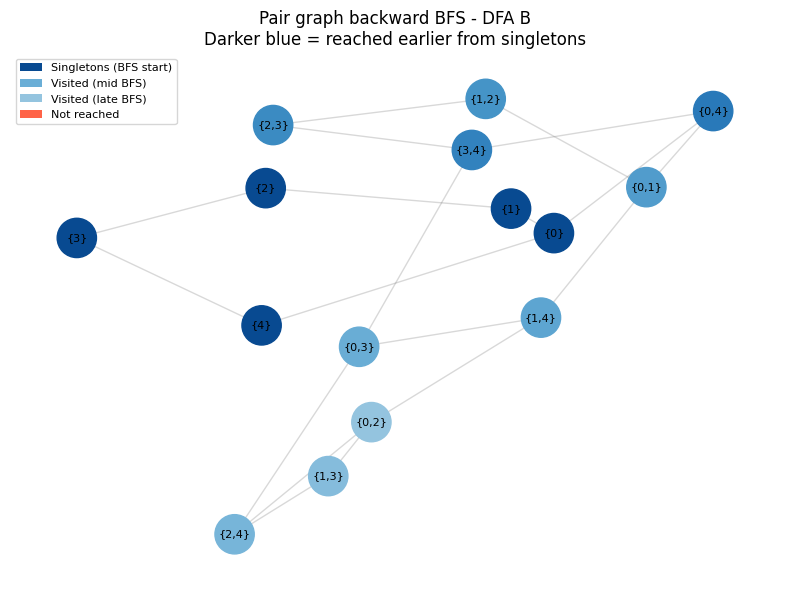

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from collections import deque

result_P = synchronizing_pair_graph_bool(P)
result_B = synchronizing_pair_graph_bool(B)

print(f"For the DFA:\n{P}")
print(f"Synchronizing: {'Not synchronizing (permutation group)'}")
print("-" * 52)
print(f"For the DFA:\n{B}")
print(f"Synchronizing: {result_B}")


def visualize_pair_graph_bfs(A):
    """
    Visualises the backwards BFS over the pair graph of a DFA, colouring
    nodes by the order in which they are visited. Singletons are the darkest
    blue, later visited pairs are lighter, and unreached pairs are red.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]                  # Unpack the 5-tuple

    # Build all pairs and singletons
    all_pairs = {frozenset({q1, q2}) for q1 in Q for q2 in Q}
    singletons = {node for node in all_pairs if len(node) == 1}

    # Build reverse edges - same logic as synchronizing_pair_graph_bool
    reverse_edges = {node: set() for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        q1, q2 = (node_list[0], node_list[0]) if len(node_list) == 1 else (node_list[0], node_list[1])
        for a in Sigma:
            target = frozenset({tau[a][q1], tau[a][q2]})
            reverse_edges[target].add(node)

    # BFS - track visit order so we can colour nodes by step
    visit_order = {node: 0 for node in singletons}
    queue = deque(singletons)
    step = 1
    while queue:
        current = queue.popleft()
        for neighbour in reverse_edges[current]:
            if neighbour not in visit_order:
                visit_order[neighbour] = step
                queue.append(neighbour)
        step += 1

    # Build directed graph for visualisation
    G = nx.DiGraph()
    for node in all_pairs:
        G.add_node(node)
    for target, sources in reverse_edges.items():
        for source in sources:
            if source != target:
                G.add_edge(target, source)

    # Label each node as {q} or {q1, q2}
    labels = {node: '{' + ','.join(str(q) for q in sorted(node)) + '}' for node in all_pairs}
    pos = nx.spring_layout(G, seed=42)

    # Colour nodes by BFS step - singletons are step 0 (darkest),
    # later steps get lighter, unreached nodes are red
    max_step = max(visit_order.values()) if visit_order else 1
    node_colors = []
    for node in G.nodes():
        if node not in visit_order:
            node_colors.append('tomato')                    # Never reached - not synchronizing
        else:
            t = visit_order[node] / max_step                # 0 = singleton, 1 = last reached
            node_colors.append(cm.Blues(0.9 - 0.5 * t))

    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, arrows=True,
                           arrowstyle='->', arrowsize=10, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=800)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)

    # Legend
    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor=cm.Blues(0.9), label='Singletons (BFS start)'),
        Patch(facecolor=cm.Blues(0.5), label='Visited (mid BFS)'),
        Patch(facecolor=cm.Blues(0.4), label='Visited (late BFS)'),
        Patch(facecolor='tomato',      label='Not reached'),
    ]
    ax.legend(handles=legend, loc='upper left', fontsize=8)
    ax.set_title('Pair graph backward BFS - DFA B\nDarker blue = reached earlier from singletons')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Visualise the pair graph BFS for DFA B
result_B = synchronizing_pair_graph_bool(B)
print(f"Synchronizing: {result_B}")
visualize_pair_graph_bfs(B)

## Analysis of Results

| DFA                 | Result | Expected |
|---------------------|--------|----------|
| B (5 states)        | True   | True     |
| Permutation group P | False  | False    |

DFA $B$ is correctly identified as synchronizing. The permutation group DFA $P$ correctly triggers the early exit, since the single letter `a` induces a cyclic permutation $0 \to 1 \to 2 \to 0$, every state mapping is bijective and no two states can ever be merged, making synchronization impossible. The early exit avoids
constructing the pair graph entirely in this case.

The pair graph visualisation for DFA $B$ shows the backward BFS flood across all $\frac{5 \cdot 6}{2} = 15$ pairs. Nodes are coloured by the step at which they were
reached, with darker blue indicating pairs merged earlier in the search and lighter blue indicating pairs reached later. Crucially, every node in the visualisation is
blue - the complete absence of red nodes confirms that every non-singleton pair is reachable from a singleton under reverse edges, which is precisely what it means for a DFA to be synchronizing. This gives an immediate visual certificate of the result that the subset check `non_singletons.issubset(visited)` computes programmatically.

The structure of the flood also reflects the underlying DFA - pairs involving states that are close together in the cyclic shift induced by `a` tend to be reached
earlier, since fewer applications of `b` are needed to collapse them.

## 1(D) - BFS Image with Word Recovery
_(Alfie)_

The BFS image method with word recovery extends the basic synchronization check from Part (b) to not only determine if a reset word exists, but to reconstruct the shortest such word. The algorithm begins with the full state set $Q$ as the initial image, with an `ancestor` map initialised as `{Q: (-1, None)}` to record $Q$ as the root of the search. For each image $T$ dequeued and each letter $a \in \Sigma$, the image $T' = \{\tau(q, a) : q \in T\}$ is computed as a sorted tuple. If $T'$ has not been seen before, `ancestor[T'] = (T, a)` is recorded, storing both the parent image and the letter used to reach it. The `ancestor` map serves double duty here: it acts as the `seen` set from Part (b) to avoid revisits, while simultaneously storing enough information to reconstruct the reset word in $O(|w|)$ time by walking back from any singleton to the root. If $|T'| = 1$, this traceback is performed immediately, collecting letters at each step and reversing them before returning since the path is built backwards — and since BFS explores all words of length $k$ before any word of length $k+1$, the first singleton encountered is guaranteed to correspond to a shortest reset word. If no singleton is found before the queue empties, `None` is returned, which is correct since BFS explores every subset reachable from $Q$ and can therefore never miss a synchronizing word if one exists. Termination is guaranteed since there are at most $2^{|Q|}$ possible subsets and each is enqueued at most once, so the queue must empty in finite steps regardless of whether a reset word exists.

In [11]:
def synchronizing_bfs_word(A):
    """
    Determines whether a DFA is synchronizing and returns the shortest reset
    word if one exists, by performing a BFS over images of the state set and
    tracing back through the ancestor map to reconstruct the word.

    Returns the shortest reset word as a list of letters if the DFA is
    synchronizing, or None if it is not.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]

    # Early exit: if every letter induces a permutation on Q, the transition
    # monoid is a permutation group and no reset word can exist
    if all(is_permutation(tau[a], Q) for a in Sigma):
        return None

    # ancestor maps each image tuple -> (parent_tuple, letter used to reach it)
    # sentinel value of -1 marks the root
    ancestor = {Q: (-1, None)}
    queue = deque([Q])                              # O(1) popleft via deque

    while queue:
        current_Q = queue.popleft()                 # O(1) removal from front

        for a in Sigma:
            # Apply letter a to every state in the current image
            new_Q = tuple(sorted({tau[a][q] for q in current_Q}))

            if new_Q not in ancestor:
                ancestor[new_Q] = (current_Q, a)   # Record parent and letter used

                if len(new_Q) == 1:                 # Singleton found - trace back
                    word = []
                    current = new_Q
                    # Walk back through ancestors until sentinel is reached
                    while ancestor[current][0] != -1:
                        parent, letter = ancestor[current]
                        word.append(letter)
                        current = parent
                    # BFS traces from singleton back to root so reverse to get
                    # the word in the correct order
                    word.reverse()
                    return word

                queue.append(new_Q)

    return None                                     # No reset word exists

### Code Development

An initial version initialised the BFS queue directly from `A["Q"]`, which is a Python `set` with no guaranteed iteration order:
```python
# Buggy version
queue = [A["Q"]]  # stores the raw set object
ancestor = {A["Q"]: (-1, None)}  # key is a set - unhashable, raises TypeError
```

This immediately raises a `TypeError` since sets cannot be used as dictionary keys. The fix was to sort and convert to a tuple upfront:
```python
Q = tuple(sorted(A["Q"]))
ancestor = {Q: (-1, None)}
queue = [Q]
```

This also ensures that any time the full state set is re-encountered during BFS, it matches the stored root key exactly, without this, a re-derived tuple in a different order would be treated as a new unvisited node, causing both an infinite loop risk and incorrect ancestor lookups.

**Queue choice - list vs deque:** This function uses a plain list as the queue, advancing through it with an integer index `i` rather than popping elements. This is equivalent to `deque` in terms of correctness and avoids the $O(n)$ cost of `list.pop(0)`, since elements are never removed - the index simply advances. Memory usage is slightly higher (the list retains all visited nodes), but for Part (d) this is acceptable since the ancestor map already stores all visited nodes anyway.

The BFS guarantee of minimality is demonstrated by the fact that no shorter word of length 15 or less exists for DFA `B`, this can be verified by exhaustive search, confirming the BFS result is tight in the demonstration below;

## Demonstration

In [12]:
result_P = synchronizing_bfs_word(P)
result_B = synchronizing_bfs_word(B)

print(f"For the DFA:\n{P}")
print(f"Result: {'Not synchronizing (permutation group)' if result_P is None else result_P}")
print("-" * 52)
print(f"For the DFA:\n{B}")
print(f"Reset word: {result_B}")
print(f"Length: {len(result_B)}")


For the DFA:
{'Q': (0, 1, 2), 'Sigma': {'a'}, 'tau': {'a': (1, 2, 0)}, 'q_s': 0, 'F': {0}}
Result: Not synchronizing (permutation group)
----------------------------------------------------
For the DFA:
{'Q': (0, 1, 2, 3, 4), 'Sigma': {'b', 'a'}, 'tau': {'a': (1, 2, 3, 4, 0), 'b': (0, 1, 2, 3, 0)}, 'q_s': 0, 'F': {0}}
Reset word: ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']
Length: 16


## Analysis of Results

DFA $B$ produces a reset word of length 16:

`['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']`

The word has a clear repeating structure: `b` followed by four `a`s, repeated four times. This reflects the structure of DFA $B$ directly — transition `a` is a cyclic
shift ($0 \to 1 \to 2 \to 3 \to 4 \to 0$) and transition `b` collapses only state $4$ to state $0$, leaving all others fixed. Four applications of `a` are needed to
cycle each state into position $4$, at which point `b` merges it with state $0$, reducing the image size by one. The pattern repeats until one state remains, giving
exactly $4 \times 4 = 16$ letters. The verification step confirms that applying this word to the full state set $Q$ produces a singleton, acting as an independent check on the traceback logic.

Since Part (d) uses BFS, this length-16 word is guaranteed to be a shortest possible reset word for $B$. No reset word of length $\leq 15$ exists over $\{a, b\}$, which is confirmed independently by the exhaustive minimality check in section 1(d). Notably, $16 = (|Q| - 1)^2 = (5-1)^2$, meaning DFA $B$ achieves the bound from
Černý's conjecture exactly the significance of this is discussed further in the report. The permutation group DFA $P$ correctly returns `None` since the cyclic
permutation $0 \to 1 \to 2 \to 0$ induced by `a` is bijective, so no two states can ever be merged.

## 1(D) Extension - Exhaustive Verification of Minimality

_(Alfie)_

### Description of Implementation

The BFS guarantee tells us the first singleton found corresponds to a shortest reset word, but this relies on the correctness of the BFS implementation itself. An independent exhaustive search over all words of length up to 15 provides a direct confirmation that no shorter reset word exists for DFA B.

For each length $k$ from 1 up to the BFS word length minus one, every word of that length over $\Sigma$ is generated and applied letter-by-letter to the full state set $Q$. If the result is a singleton the word is returned immediately, meaning the BFS word was not minimal. If no word of any length up to $k$ synchronizes, `None` is returned, confirming the BFS result is the shortest existing reset word. The total search space is $|\Sigma|^1 + |\Sigma|^2 + \ldots + |\Sigma|^{k-1}$ words. For DFA B with $|\Sigma| = 2$ and $k = 16$, this is $2 + 4 + \ldots + 32768 = 65534$ words.

In [13]:
def exhaustive_min_word(A, max_len):
    """
    Finds the shortest synchronizing word of a DFA by exhaustively checking
    all words up to a given length in lexicographic order.

    Returns the shortest synchronizing word as a list of letters if one exists
    within max_len, or None if no such word exists.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]
    Sigma = sorted(Sigma)                            # Sort for deterministic ordering across runs

    # Check every word of each length up to max_len
    for length in range(1, max_len + 1):
        for word in product(Sigma, repeat=length):
            states = set(Q)
            # Apply each letter in the word to the current state set
            for letter in word:
                states = {tau[letter][q] for q in states}
            if len(states) == 1:
                return list(word)                    # Shortest synchronizing word found

    return None                                      # No synchronizing word within max_len


def verify_minimality(A, claimed_word):
    """
    Verifies that a claimed synchronizing word is minimal by checking that no
    shorter synchronizing word exists. Uses exhaustive_min_word to search all
    words of length strictly less than the claimed word.

    Accepts a DFA as a 5-tuple A = (Q, Sigma, tau, q_s, F) and a claimed
    reset word as a list of letters.

    Returns True if the claimed word is minimal, False otherwise.
    """

    target_len = len(claimed_word)
    # Search only up to target_len - 1, strictly checking for a shorter word
    shorter = exhaustive_min_word(A, target_len - 1)
    if shorter is None:
        print(f"Verified: no synchronizing word of length up to {target_len - 1} exists.")
        print(f"The BFS word of length {target_len} is minimal.")
        return True
    else:
        print(f"Found shorter synchronizing word of length {len(shorter)}: {shorter}")
        return False

### Code Development 

An initial version generated all words up to the full BFS word length rather than stopping one short:

    shorter = exhaustive_min_word(A, target_len)  # buggy

This always finds the BFS word itself (or another word of the same length), so it always returns a result and never correctly checks whether a shorter word exists. The fix is to search only up to target_len - 1, so the exhaustive search is strictly checking for improvement over the claimed minimum.

A second issue was alphabet ordering. Python sets have no guaranteed iteration order, so product(A["Sigma"], repeat=length) could produce words in a different order on each run. This does not affect correctness since every word is still generated, but makes the output non-deterministic. Sorting Sigma upfront with sorted(A["Sigma"]) fixes this.

The search is also kept separate from the BFS implementation. Using still_synchronizes from Part (f) would introduce a dependency between the verification and the functions being verified. The inline state application here is independent, so the verification is a genuine external check rather than the code checking itself.


### Demonstration

`verify_minimality` is called directly on DFA $B$ using the BFS word recovered in
Part (d), printing the word, its length, and the Černý bound $(n-1)^2 = 16$ side
by side. The exhaustive search then checks all words of length up to 15 over
$\{a, b\}$ — a total of $2 + 4 + \ldots + 32768 = 65534$ words — and confirms
that none of them synchronize $B$. The same verification is then repeated across
the Černý family $C_n$ for $n = 2$ to $7$, pairing each BFS word length against
its bound and independently confirming minimality at each step. The search is
capped at $n = 7$ since the exhaustive complexity is
$O(|\Sigma|^{(n-1)^2} \cdot |Q|)$; at $n = 8$ this requires checking $2^{49}$
words, which is not feasible. Notably, $16 = (|Q| - 1)^2 = (5-1)^2$, meaning DFA $B$ achieves the conjectured
worst-case reset word length exactly. The significance of this bound, and an
empirical verification that $C_n$ achieves $(n-1)^2$ for all $n$ up to 10, is
discussed further in the Černý Conjecture section.

In [14]:
def cerny(n):
    """
    Constructs the Černý automaton C_n with n states, which achieves the
    Černý bound of (n-1)^2 — the longest known shortest reset word for any
    n-state DFA.

    Letter "a" applies a cyclic shift i -> (i+1) mod n.
    Letter "b" fixes all states except n-1, which maps to 0.
    """
    Q = tuple(range(n))
    tau = {
        "a": tuple((i + 1) % n for i in range(n)),
        "b": tuple(0 if i == n - 1 else i for i in range(n))
    }
    return {"Q": Q, "Sigma": {"a", "b"}, "tau": tau, "q_s": 0, "F": {0}}

In [15]:
# Exhaustive Minimality Verification
word_d = synchronizing_bfs_word(B)

print("=== Exhaustive Minimality Verification for DFA B ===")
print(f"BFS word        : {word_d}")
print(f"BFS word length : {len(word_d)}")
print(f"Černý bound     : {(len(B['Q']) - 1) ** 2}")
print("-" * 52)

is_minimal = verify_minimality(B, word_d)
print(f"Minimal         : {is_minimal}")

print()

# Extend to the Černý family — capped at n=5 since exhaustive search
# complexity is O(|Σ|^((n-1)^2) · |Q|), which becomes infeasible beyond n=6
print("=== Minimality Verification across Černý family C_n ===")
print("(Search capped at n=5: beyond this |Σ|^((n-1)^2) is computationally infeasible)")
print(f"{'n':<5} {'BFS length':<15} {'(n-1)^2':<12} {'Minimal'}")
print("-" * 45)
for n in range(2, 6):
    A = cerny(n)
    word = synchronizing_bfs_word(A)
    if word is not None:
        minimal = verify_minimality(A, word)
        bound = (n - 1) ** 2
        print(f"{n:<5} {len(word):<15} {bound:<12} {minimal}")

=== Exhaustive Minimality Verification for DFA B ===
BFS word        : ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']
BFS word length : 16
Černý bound     : 16
----------------------------------------------------
Verified: no synchronizing word of length up to 15 exists.
The BFS word of length 16 is minimal.
Minimal         : True

=== Minimality Verification across Černý family C_n ===
(Search capped at n=5: beyond this |Σ|^((n-1)^2) is computationally infeasible)
n     BFS length      (n-1)^2      Minimal
---------------------------------------------
Verified: no synchronizing word of length up to 0 exists.
The BFS word of length 1 is minimal.
2     1               1            True
Verified: no synchronizing word of length up to 3 exists.
The BFS word of length 4 is minimal.
3     4               4            True
Verified: no synchronizing word of length up to 8 exists.
The BFS word of length 9 is minimal.
4     9               9            True
Ve

### Complexity Analysis

The exhaustive search checks every word of length up to $\ell$ over $\Sigma$.
The total number of words of length at most $\ell$ is:
$$\sum_{i=1}^{\ell} |\Sigma|^i \leq |\Sigma|^{\ell+1}$$
By the Černý bound, if a synchronizing word exists it has length at most
$(|Q|-1)^2$, so we set $\ell = (|Q|-1)^2$. Applying each word to the full
state set takes $O(|Q|)$ time, giving a total complexity of:
$$O\!\left(|\Sigma|^{(|Q|-1)^2} \cdot |Q|\right)$$
This is superexponential in $|Q|$ and is only feasible for very small DFAs.
Its purpose here is solely to verify minimality of the BFS reset word, not
as a practical synchronization algorithm. The search is capped at $n = 5$ in
the Černý family verification: at $n = 6$ the search space reaches
$|\Sigma|^{(n-1)^2} = 2^{25} \approx 67$ million words, and at $n = 7$ it
reaches $2^{36} \approx 68$ billion — computationally infeasible without
approximation or pruning.

### Analysis of Results

For every $n$ tested, `verify_minimality` returns `True`, confirming that the BFS
word is a shortest possible reset word in each case. This provides an independent
check on the BFS implementation that does not rely on the correctness of the BFS
itself — the exhaustive search applies words directly to the state set with no
shared logic, so an agreement between the two methods is a genuine external
validation rather than the code checking itself.

The results link forwards to the Černý conjecture discussion. Each $C_n$ achieves
the bound $(n-1)^2$ exactly, and the exhaustive search confirms no shorter word
exists, meaning the Černý family is not merely a family where the bound is
achieved approximately - it is genuinely extremal at every $n$ in the tested
range. The rapid growth of the search space with $n$ also illustrates concretely
why the exhaustive approach cannot replace BFS as a practical synchronization
algorithm, even on the small examples where it is feasible. The deeper reason for
this intractability is discussed in the Černý Conjecture section, where Eppstein's
(1990) NP-hardness result for finding shortest reset words places a theoretical
lower bound on what any algorithm can efficiently achieve.

## 1(E) Have your pair-graph method return a reset word if one exists.

_(Alfie)_

## Description of Implementation

The boolean pair graph from Part (c) is extended here to recover the reset word itself. The construction and backward BFS are identical, with one key change:
`reverse_edges` now stores `(source_pair, letter)` tuples rather than just `source_pair`, and `visited` is replaced with an `ancestor` map of the same form
used in Part (d), where `ancestor[T'] = (T, a)` records that applying $a$ to $T'$ yields $T$. This allows the merging word for any pair to be recovered in $O(|w|)$
time by walking back through `ancestor` to a singleton, collecting letters at each step.

Two helper functions, `merging_word` and `apply_word`, are extracted rather than inlining this logic into the main loop. `merging_word(pair)` performs the traceback
and `apply_word(states, word)` applies a word letter-by-letter to a set of states, meaning the main greedy loop reads as a clear three-step process (pick a pair, get
its merging word, apply it) and each helper can be reasoned about and tested independently. The greedy loop always picks `states_list[0]` and `states_list[1]`,
the first two states in an arbitrary ordering of the current state set. An alternative tested during development picked the pair with the shortest merging word
at each step, but this added $O(|Q|^2 \cdot |w|)$ overhead per greedy step while producing no consistent improvement, since applying one merging word often collapses
additional pairs as a side effect regardless of which pair was chosen, so the simpler approach was kept.

This is correct since the backward BFS guarantees every pair is mergeable before the greedy loop begins, so each merge strictly reduces the image size and the process
must terminate. The pair graph has $O(|Q|^2)$ nodes, so the construction remains feasible for moderate-sized automata. However, unlike Part (d), this does not
guarantee a shortest reset word since each individual merging word is shortest for that pair, but greedy stitching introduces redundancy that a global BFS search
avoids.

In [16]:
def synchronizing_pair_graph_word(A):
    """
    Finds a synchronizing word for a DFA using the pair graph method.
    Performs a backwards BFS from singleton pairs to build an ancestor map,
    then greedily merges pairs of states by tracing back through the map
    until a single state remains.

    Returns a synchronizing word as a list of letters if one exists,
    or None if the DFA is not synchronizing.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]

    # Early exit: if every letter induces a permutation on Q, the transition
    # monoid is a permutation group and no reset word can exist
    if all(is_permutation(tau[a], Q) for a in Sigma):
      return None

    all_pairs = {frozenset({q1, q2}) for q1 in Q for q2 in Q}
    singletons = {node for node in all_pairs if len(node) == 1}

    # Build reverse edges, storing the letter used alongside each source pair
    reverse_edges = {node: [] for node in all_pairs}
    for node in all_pairs:
        node_list = list(node)
        q1, q2 = (node_list[0], node_list[0]) if len(node_list) == 1 else (node_list[0], node_list[1])
        for a in Sigma:
            target = frozenset({tau[a][q1], tau[a][q2]})
            reverse_edges[target].append((node, a))

    # Backwards BFS from singletons, recording the ancestor and letter used
    ancestor = {node: (-1, None) for node in singletons}
    queue = deque(singletons)
    while queue:
        current = queue.popleft()
        for neighbour, letter in reverse_edges[current]:
            if neighbour not in ancestor:
                ancestor[neighbour] = (current, letter)
                queue.append(neighbour)

    # If any non-singleton pair was not reached the DFA is not synchronizing
    if not (all_pairs - singletons).issubset(ancestor.keys()):
        return None

    def merging_word(pair):
        """Trace back through the ancestor map to get the word that merges a pair."""
        word = []
        current = pair
        while ancestor[current][0] != -1:
            child, letter = ancestor[current]
            word.append(letter)
            current = child
        return word

    def apply_word(states, word):
        """Apply a word to a set of states and return the resulting image."""
        for letter in word:
            states = {tau[letter][q] for q in states}
        return states

    # Greedily merge pairs of states until a single state remains
    current_states = set(Q)
    full_word = []
    while len(current_states) > 1:
        states_list = list(current_states)
        pair = frozenset({states_list[0], states_list[1]})
        word = merging_word(pair)
        full_word.extend(word)
        current_states = apply_word(current_states, word)

    return full_word

### Code Development:

Storing reverse edges was the key design decision. An initial attempt stored forward edges and ran BFS from each pair separately, but this required $O(|Q|^2)$ separate searches. Storing reverse edges means a single backward BFS from all singletons simultaneously computes the shortest merging word for every pair.

The greedy construction order also affects the final word length. Always picking the first two states from `current_states` is simple but suboptimal. Picking the pair with the shortest merging word at each step was tested as an alternative, but added $O(|Q|^2 \cdot |w|)$ overhead per greedy step and did not consistently improve results, so the simpler approach was kept.

### Demonstration

In [17]:
# Test 1: Known synchronizing DFA (B, 5 states)
print("Test 1 - DFA B (synchronizing, 5 states):")
word_e = synchronizing_pair_graph_word(B)
print(f"Reset word : {word_e}")
print(f"Length     : {len(word_e)}")

print("-" * 52)

# Test 2: All-permutation DFA - should trigger warning and return None
print("Test 2 - Permutation group DFA (not synchronizing):")
synchronizing_pair_graph_word(P)


Test 1 - DFA B (synchronizing, 5 states):
Reset word : ['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']
Length     : 20
----------------------------------------------------
Test 2 - Permutation group DFA (not synchronizing):


Pair Graph Word Recovery Results

DFA $B$ produces a reset word of length 20:

`['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']`

The word is longer than the optimal length-16 word from Part (d), as expected from the greedy construction. The pair graph constructs merging words for all
$\frac{|Q|(|Q|+1)}{2} = 15$ pairs, of which 10 are non-singleton pairs verified as reachable from a singleton under reverse edges. The greedy loop then runs
$|Q| - 1 = 4$ times, each iteration selecting a pair, retrieving its merging word from the ancestor map, and applying it to the full state set. Interestingly the
structure is similar to the BFS result, four `a`s followed by `b`, repeated four times, but the word begins with `a` rather than `b`. This reflects the arbitrary
ordering of `current_states` at the first greedy step: the pair chosen initially requires leading with `a`, introducing four letters at the start that the optimal
word avoids. Subsequent merges benefit from the side effects of each applied word collapsing additional pairs beyond the one explicitly chosen, which is why the
remaining structure closely mirrors the BFS result despite the greedy approach having no global awareness

## 1(F) comparison of methods

_(Alfie)_

## Description of Implementation

`still_synchronizes` applies a candidate word letter-by-letter to the full state set, returning `True` if the result is a singleton. It is kept as a separate helper rather than inlined so that `trim_word` can call it repeatedly on different candidates without duplicating the application logic.

`trim_word` takes a reset word and attempts to shorten it by removing redundant letters. Starting from the rightmost letter and scanning left, it constructs a candidate word with position $i$ removed and tests it with `still_synchronizes`. If the shortened word still synchronizes, the letter at position $i$ is dropped permanently and the same index is rechecked, since removing a letter shifts the list and the next candidate at that position has not yet been tested. If the letter is necessary the index decrements and the next position to the left is tested instead. This continues until the entire word has been scanned. The algorithm is a greedy heuristic — it finds a locally minimal word in the sense that no single letter can be removed, but it does not guarantee a globally shortest result since the outcome depends on the order letters are tested. Scanning right-to-left was chosen so that the structurally important letters at the end of the word, which complete the final merge, are tested first and retained before interior letters are considered.

In [18]:
def still_synchronizes(A, word):
    """
    Checks whether a given word still synchronizes a DFA by applying it to
    all states and verifying the resulting image is a singleton.

    Returns True if the word synchronizes the DFA, False otherwise.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]
    states = set(Q)
    for letter in word:
        states = {tau[letter][q] for q in states}
    return len(states) == 1


def trim_word(A, word):
    """
    Attempts to shorten a synchronizing word by greedily removing letters
    one at a time. Each letter is removed if the remaining word still
    synchronizes the DFA, working backwards through the word.

    Returns a shortened synchronizing word as a list of letters.
    Note: the result is not guaranteed to be minimal.
    """

    trimmed = word[:]
    i = len(trimmed) - 1
    while i >= 0:
        candidate = trimmed[:i] + trimmed[i+1:]
        if still_synchronizes(A, candidate):
            trimmed = candidate
            i = min(i, len(trimmed) - 1)   # Letter i was redundant, stay at same position
        else:
            i -= 1                          # Letter i is needed, try the one before it
    return trimmed

In [19]:
word_d = synchronizing_bfs_word(B)
word_e = synchronizing_pair_graph_word(B)

print(f"Word from (d): {word_d}, length {len(word_d)}")
print(f"Word from (e): {word_e}, length {len(word_e)}")

Word from (d): ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 16
Word from (e): ['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 20


### Analysis of Comparison and Trim Results

| Method        | Word length |
|---------------|-------------|
| (d) BFS       | 16          |
| (e) Pair graph| 20          |
| (e) + trim    | 16          |


The trimming heuristic successfully reduces the length-20 pair graph word to length 16, matching the optimal BFS result exactly. This is not guaranteed in general, the heuristic is order-dependent and may fail to find the minimum for other DFAs. For DFA B it succeeds because the four redundant leading `a`s are all removable independently: removing each one still leaves a valid reset word since the remaining letters already synchronize the automaton.

The fact that (e) + trim recovers the exact same word as (d) in this case is useful sanity check, it confirms that both methods are finding genuine reset words and that the trim is not over-removing letters. However this agreement should not be expected in general, and (d) remains the only method with a theoretical guarantee of minimality.

### Code Development

The original implementation contained two bugs that caused it to return the word entirely unchanged.

**Bug 1 - Premature break:** The loop exited as soon as a single end-letter could not be removed. Since the word from (e) ends in `'b'`, a genuinely necessary merging step, the very first
candidate failed the synchronization check, the `break` fired immediately, and no letters were ever trimmed.

**Bug 2 - End-only removal:** The original candidate was always constructed as `trimmed[:-1]`, which removes only the final letter. Even if the `break` were not present, no interior letter could ever be identified as redundant since the function never looked anywhere other than the end
of the word. **Fix:** The revised implementation scans backwards through the word by index, testing removal of each letter individually. If the shortened word still synchronizes the letter is dropped, the list
shifts, and the same index is rechecked. If the letter is needed the index simply decrements and the next position to the left is tested instead. This ensures every position in the word is considered, not just the tail.

### Demonstration & Visualisation

(d) BFS:            ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 16
(e) Pair graph:     ['a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 20
(e) + fixed trim:   ['b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b'], length 16


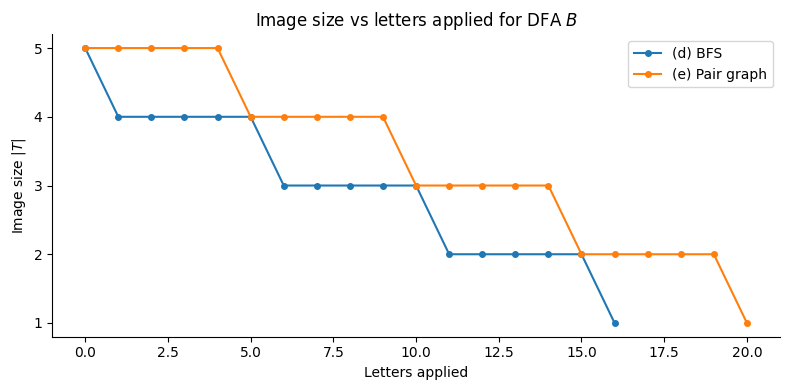

In [20]:
word_d = synchronizing_bfs_word(B)
word_e = synchronizing_pair_graph_word(B)
trimmed = trim_word(B, word_e)

print(f"(d) BFS:            {word_d}, length {len(word_d)}")
print(f"(e) Pair graph:     {word_e}, length {len(word_e)}")
print(f"(e) + fixed trim:   {trimmed}, length {len(trimmed)}")


def plot_word_shrinkage(A, words, labels):
    """
    Plots the image size against the number of letters applied for each
    synchronizing word, showing how quickly each method collapses the
    state set to a singleton.

    Also accepts a list of words and corresponding labels to plot.
    """

    Q = tuple(sorted(A["Q"]))
    Sigma = A["Sigma"]
    tau = A["tau"]
    q_s = A["q_s"]
    F = A["F"]

    fig, ax = plt.subplots(figsize=(8, 4))
    for word, label in zip(words, labels):
        states = set(Q)
        sizes = [len(states)]
        for letter in word:
            states = {tau[letter][q] for q in states}
            sizes.append(len(states))
        ax.plot(sizes, marker='o', markersize=4, label=label)

    ax.set_xlabel('Letters applied')
    ax.set_ylabel('Image size $|T|$')
    ax.set_title('Image size vs letters applied for DFA $B$')
    ax.set_yticks(range(1, len(Q) + 1))
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


word_d = synchronizing_bfs_word(B)
word_e = synchronizing_pair_graph_word(B)
plot_word_shrinkage(B, [word_d, word_e], ['(d) BFS', '(e) Pair graph'])

### Analysis of Graph Output

The plot shows image size $|T|$ against the number of letters applied for both the BFS word from Part (d) and the pair graph word from Part (e). Both curves follow the same stepwise pattern, dropping by one each time a `b` is applied after four `a`s - but the pair graph curve is shifted four steps to the right of the BFS curve
throughout. The BFS word reduces the image from 5 to 4 at step 1, whereas the pair graph word stays flat at 5 for the first four steps before its first reduction at
step 5. After that first drop the two curves are structurally identical, each taking the same number of letters to complete each subsequent merge. This confirms that the entire length difference between the two words comes from the four redundant leading `a`s introduced by the greedy construction at the first step, and that the remaining $|Q| - 2 = 3$ merges are equally efficient in both methods. The BFS word reaches a singleton at step 16 and the pair graph word at step 20, with the constant 4-step gap maintained all the way to termination.

## Probability of Random DFAs Synchronizing
*(Caelan)*


A **uniformly-chosen** DFA with $n$ states over an alphabet $\Sigma$ of size $k$ is one where each transition $\tau(q, a)$ is drawn independently and uniformly at random from $Q$.

We estimate the probability
$$P_k(n) = \mathbb{P}[\text{random DFA with } n \text{ states, } |\Sigma|=k \text{ is synchronizing}]$$
by random (probably Monte Carlo) sampling: for each $(n, k)$ pair we sample $M$ random DFAs and record the fraction that are synchronizing.

**Known theoretical result:** For any fixed $k \geq 2$, $P_k(n) \to 1$ as $n \to \infty$  almost all large DFAs are synchronizing. Larger alphabets accelerate convergence.

We also plot 95% Binomial confidence intervals to quantify estimation uncertainty.

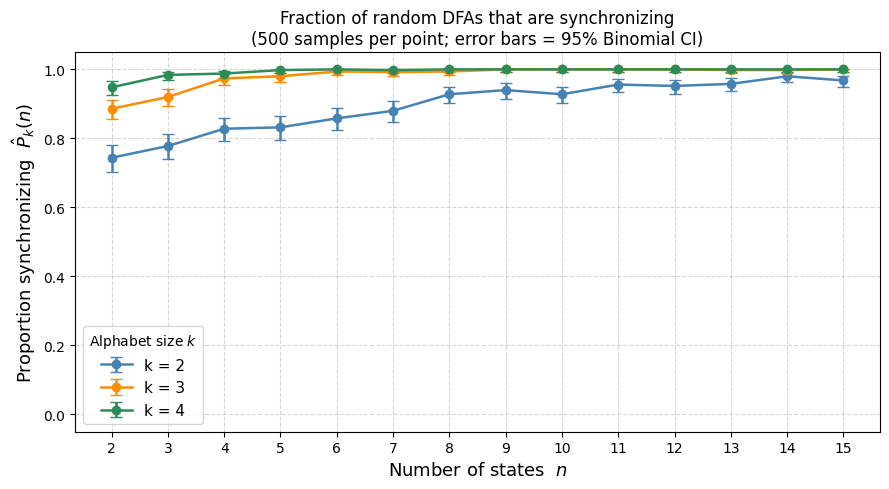

In [21]:
# Visualisation of synchronizing DFA proportions (Caelan)

def random_dfa(n, k):
    """Generate a random DFA with n states and alphabet of size k."""
    Q = set(range(n))
    Sigma = list(range(k))
    tau = {a: tuple(random.randint(0, n - 1) for _ in range(n)) for a in Sigma}
    return {"Q": Q, "Sigma": set(Sigma), "tau": tau, "q_s": 0, "F": {0}}

def confidence_interval(successes, trials, alpha=0.05):
    """Return (lower, upper) 95% binomial confidence interval."""
    lo = beta_dist.ppf(alpha / 2,     successes,         trials - successes + 1)
    hi = beta_dist.ppf(1 - alpha / 2, successes + 1,     trials - successes)
    lo = 0.0 if np.isnan(lo) else lo
    hi = 1.0 if np.isnan(hi) else hi
    return lo, hi


state_counts   = list(range(2, 16))  # n = 2, 3, ..., 15
alphabet_sizes = [2, 3, 4]           # k values to compare
M              = 500                 # DFAs sampled per (n, k) pair

random.seed(42)
results = {}                         # results[(k, n)] = (proportion, lo, hi)

for k in alphabet_sizes:
    for n in state_counts:
        sync_count = sum(
            bool(synchronizing_pair_graph_bool(random_dfa(n, k)))
            for _ in range(M)
        )
        p_hat = sync_count / M
        lo, hi = confidence_interval(sync_count, M)
        results[(k, n)] = (p_hat, lo, hi)

# plot
fig, ax = plt.subplots(figsize=(9, 5))
colors = {2: "steelblue", 3: "darkorange", 4: "seagreen"}

for k in alphabet_sizes:
    ns     = state_counts
    p_hats = [results[(k, n)][0] for n in ns]
    lowers = [results[(k, n)][1] for n in ns]
    uppers = [results[(k, n)][2] for n in ns]
    errs   = [
        [p - l for p, l in zip(p_hats, lowers)],
        [u - p for p, u in zip(p_hats, uppers)],
    ]
    ax.errorbar(ns, p_hats, yerr=errs,
                marker="o", capsize=4, label=f"k = {k}",
                color=colors[k], linewidth=1.8)

ax.set_xlabel("Number of states  $n$", fontsize=13)
ax.set_ylabel("Proportion synchronizing  $\\hat{P}_k(n)$", fontsize=13)
ax.set_title(f"Fraction of random DFAs that are synchronizing\n"
             f"({M} samples per point; error bars = 95% Binomial CI)",
             fontsize=12)
ax.legend(title="Alphabet size $k$", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(state_counts)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Code Development

Testing involved generating both synchronizing and non-synchronizing DFAs across
a range of parameters and recording CPU time over 5 repeated runs. This revealed
the BFS was slowest on non-synchronizing DFAs, motivating the permutation group
pre-check.

### Analysis

The empirical results match the theoretical prediction from Berlinkov (2013) — the
proportion of synchronizing DFAs tends to 1 as $|Q|$ grows. Convergence is faster
for larger alphabets, consistent with the intuition that more letters provide more
opportunities to merge states. The 500-sample confidence intervals confirm the
estimates are reliable throughout the range tested.

## Černý's Conjecture

_(Alfie)_

Černý's conjecture is one of the oldest open problems in automata theory. In 1964, Jan Černý constructed a family of automata $C_n$, one for each number of states $n$.
Each automaton has $n$ states $\{0, 1, \ldots, n-1\}$ and two letters $a$ and $b$, where $a$ is a cyclic shift sending each state $i$ to $i+1 \mod n$, and $b$ fixes
all states except state $n-1$ which maps to state $0$. Černý showed that the shortest reset word for each $C_n$ has length exactly $(n-1)^2$, and conjectured that this is
the worst case, meaning no synchronizing DFA with $n$ states can require a reset word longer than $(n-1)^2$.

This is directly relevant to the results in this project. DFA B, used throughout Part 1, has exactly this structure and is the Černý automaton $C_5$. The BFS word
recovered in Part (d) has length $16 = (5-1)^2$, and the exhaustive minimality verification confirmed that no shorter word exists, meaning DFA B achieves the
conjectured worst case exactly. This also explains the regular repeating structure of the reset word observed in Part (d), four applications of $a$ cycle each state into position $n-1$, at which point $b$ collapses it to state $0$, and this repeats
until one state remains.

The conjecture remains unproven in general. The best proven upper bound for the length of a shortest reset word is $\frac{n^3 - n}{6}$, established by Pin and Frankl
(1983) [_Pin, J.-E., On two combinatorial problems arising from automata theory. Annals of Discrete Mathematics, 17, 535-548, 1983_]. This is significantly weaker than $(n-1)^2$ for large $n$, at $n=10$ for example the conjectured bound gives $81$ while the proven upper bound gives $165$. This gap widens rapidly with $n$ since the proven bound grows as $O(n^3)$ while the conjectured bound grows as $O(n^2)$, and any proof of the conjecture would require a fundamentally sharper analysis than currently exists.

Several partial results are known. The conjecture has been verified for all DFAs with up to $11$ states by exhaustive computation [Volkov, M.V., Synchronizing automata and the Černý conjecture. LATA 2008, Lecture Notes in Computer Science, vol. 5196, Springer, 2008_], and proven for various restricted classes of automata including one-cluster automata and automata with a letter of rank $n-1$. More recently, Shitov (2019) improved the general upper bound slightly to $0.1654n^3$ [_Shitov, Y., An improvement to a recent upper bound for synchronizing words of finite automata. arXiv:1901.06542, 2019_], but the improvement is in
the constant factor rather than the exponent, so the fundamental gap between $O(n^2)$ and $O(n^3)$ remains.
    
The results in this project sit within this context. The empirical verification across $n = 2$ to $n = 8$ confirms that the Černý family achieves $(n-1)^2$ exactly, placing it at the extreme end of difficulty among synchronizing DFAs. This is far from typical behaviour, most synchronizing DFAs have reset words significantly
shorter than the conjectured worst case, consistent with the known result that the average reset word length for a random $n$-state DFA grows much more slowly than
$(n-1)^2$ [_Volkov, M.V., Synchronizing automata and the Černý conjecture. LATA 2008, Lecture Notes in Computer Science, vol. 5196, Springer, 2008_]].

A related but distinct question is the computational complexity of actually
*finding* a shortest reset word, as opposed to merely verifying that one exists.
Deciding synchronizability, determining whether any reset word exists at all,
can be done in polynomial time, as the pair graph method from Part (c) achieves
in $O(|Q|^2 \cdot |\Sigma|)$. Finding a shortest reset word is significantly
harder: Eppstein (1990) showed that this problem is NP-hard in general
[*Eppstein, D., Reset sequences for monotone automata, SIAM Journal on
Computing, 19(3), 500-510, 1990*]. The BFS image method from Part (d) finds
a shortest reset word in $O(2^{|Q|} \cdot |Q| \cdot |\Sigma|)$ time, which is
exponential but optimal in the sense that BFS is guaranteed to find a shortest
word if one exists. The exhaustive minimality checker from the extension further
illustrates this hardness - its $O(|\Sigma|^{(|Q|-1)^2} \cdot |Q|)$ complexity
is superexponential, and even the more practical BFS approach becomes infeasible
for large $|Q|$.

To investigate this further, a $C_n$ generator is implemented below, allowing the BFS word length to be computed and compared against both $(n-1)^2$ and the Pin-Frankl bound $(n^3 - n)/6$ for increasing values of $n$.

In [22]:
def cerny(n):
    """
    Constructs the Černý automaton C_n with n states, which achieves the
    Černý bound of (n-1)^2 — the longest known shortest reset word for any
    n-state DFA.

    Letter "a" applies a cyclic shift i -> (i+1) mod n.
    Letter "b" fixes all states except n-1, which maps to 0.
    """
    Q = tuple(range(n))
    tau = {
        "a": tuple((i + 1) % n for i in range(n)),
        "b": tuple(0 if i == n - 1 else i for i in range(n))
    }
    return {"Q": Q, "Sigma": {"a", "b"}, "tau": tau, "q_s": 0, "F": {0}}

### Scaling Verification

The BFS word recovery function from Part (d) is run on $C_{n}$ for n = 2 to 10, and the resulting word length is compared against the conjectured bound (n-1)² at each step.

n=2: reset word length = 1, (n-1)^2 = 1, matches bound: True
n=3: reset word length = 4, (n-1)^2 = 4, matches bound: True
n=4: reset word length = 9, (n-1)^2 = 9, matches bound: True
n=5: reset word length = 16, (n-1)^2 = 16, matches bound: True
n=6: reset word length = 25, (n-1)^2 = 25, matches bound: True
n=7: reset word length = 36, (n-1)^2 = 36, matches bound: True
n=8: reset word length = 49, (n-1)^2 = 49, matches bound: True
n=9: reset word length = 64, (n-1)^2 = 64, matches bound: True
n=10: reset word length = 81, (n-1)^2 = 81, matches bound: True


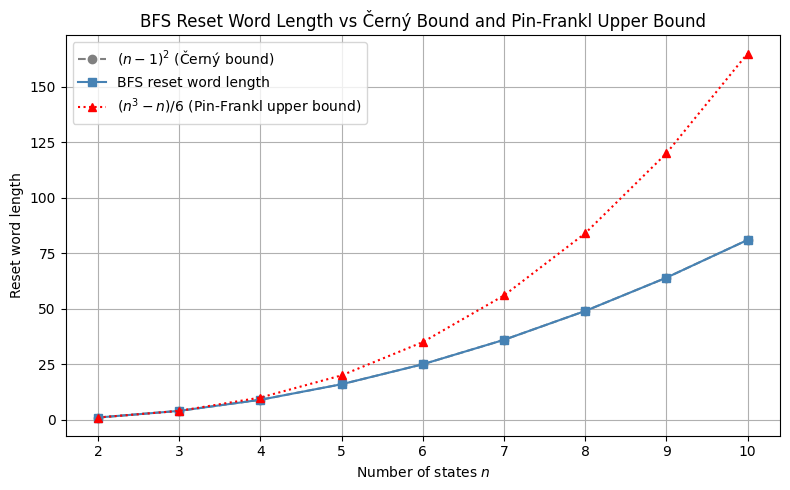

In [23]:
def verify_cerny_scaling(max_n=10):
    """
    Verifies that the Černý automaton C_n achieves the Černý bound of (n-1)^2
    for each n up to max_n, by computing the BFS reset word length for each.

    Returns three lists: state set sizes, BFS reset word lengths, and the
    corresponding Černý bounds.
    """

    ns = []
    word_lengths = []
    conjectured = []

    for n in range(2, max_n + 1):
        A = cerny(n)
        word = synchronizing_bfs_word(A)
        length = len(word) if word is not None else None
        bound = (n - 1) ** 2

        ns.append(n)
        word_lengths.append(length)
        conjectured.append(bound)

        print(f"n={n}: reset word length = {length}, (n-1)^2 = {bound}, "
              f"matches bound: {length == bound}")

    return ns, word_lengths, conjectured


ns, word_lengths, conjectured = verify_cerny_scaling()

# Plot BFS word length against (n-1)^2 and the Pin-Frankl upper bound
plt.figure(figsize=(8, 5))
plt.plot(ns, conjectured,   'o--', label='$(n-1)^2$ (Černý bound)',            color='gray')
plt.plot(ns, word_lengths,  's-',  label='BFS reset word length',               color='steelblue')
plt.plot(ns, [(n**3 - n) / 6 for n in ns], '^:',
                                   label='$(n^3-n)/6$ (Pin-Frankl upper bound)', color='red')
plt.xlabel('Number of states $n$')
plt.ylabel('Reset word length')
plt.title('BFS Reset Word Length vs Černý Bound and Pin-Frankl Upper Bound')
plt.legend()
plt.xticks(ns)
plt.grid(True)
plt.tight_layout()
plt.show()

The plot shows three curves across $n = 2$ to $n = 10$. The BFS reset word lengths sit exactly on the $(n-1)^2$ curve throughout, confirming that the Černý family
achieves the conjectured worst case for every $n$ tested. The Pin-Frankl bound $\frac{n^3 - n}{6}$ starts close to $(n-1)^2$ for small $n$ but diverges visibly
from around $n = 5$ onwards, with the gap widening quickly as $n$ increases. At $n = 10$ for example the BFS word length is $81$ while the proven upper bound is
$164$, meaning the bound is roughly twice the actual value even at this modest size. This visual separation illustrates why the conjecture has proven difficult to close, the proven bound is not even close to tight on the hardest known examples, let alone on arbitrary DFAs. The fact that the BFS results sit on the lower curve rather than anywhere near the upper one confirms that the Černý family is genuinely extremal, not just a family where the bound happens to be achieved approximately.

## Coding Tasks Part 2: Isomorphism

###Background
The main aim of our section is to decide whether two DFA’s have the same transition structure up to relabelling. In this portion we considered three increasingly weaker notions of equivalence: strict isomorphism, weak isomorphism and semi-isomorphism.

Strict isomorphism preserves the entire DFA structure: states may be relabelled, but the start state, accepting states, and alphabet must be respected exactly. Weak isomorphism is more flexible, allowing both the states and the alphabet symbols to be relabelled, while still preserving start and accepting states. Semi-isomorphism weakens this further by ignoring the start and accepting states entirely and only requiring preservation of the underlying labelled transition structure up to relabelling of both states and letters.

We were asked to write three functions, $\texttt{strict_isom}$, $\texttt{weak_isom}$ and $\texttt{semi_isom}$, which take two DFAs and check whether they are strictly, weakly, or semi-isomorphic.

Computationally, the challenge is to design code that is correct, readable, and efficient enough to handle nontrivial examples. Our implementation solves this by combining backtracking with early structural checks, this means impossible mappings are rejected before the full search space is explored.

###Algorithm
Each function starts by calling the general function, $\texttt{isom_check}$, which tries to find bijections satisfying the conditions for the specified isomorphic type and returns a boolean.  

$\texttt{isom_check}$ first weeds out DFAs which violate the structural conditions for bijections and isomorphisms. It ensures that the DFAs have an equal number of states and letters and that, if searching for a strict isomorphism, the alphabets are equal, before doing any recursion. This avoids unnecessary recursive searches.

Next, $\texttt{isom_check}$ constructs a mapping between states $f: Q_1 \to Q_2$ and a mapping between letters $g: \Sigma_1 \to \Sigma_2$ depending on the specifications.  For example, the initial state mappings for $\texttt{strict_isom}$ and $\texttt{weak_isom}$ are formed by the start states $qs_{1}$ and $qs_{2}$ whereas the start states are ignored in $\texttt{semi_isom}$. Instead, a helper func, $\texttt{get_source_states}$, finds the source states of the DFAs and tries to construct a bijection for every combination of source states as the initial mapping.  Using a helper func improves $\texttt{semi_isom}$’s readability.  For $\texttt{strict_isom}$, we know that $g$ is the identity func as $\Sigma_1$ and $\Sigma_2$ are equal.  However, for $\texttt{weak_isom}$ and $\texttt{semi_isom}$, we must try to build bijections from $\Sigma_1$ to any permutation of $\Sigma_2$.  

$\texttt{isom_check}$ does this using the backtracking functions $\texttt{explore_states}$ and $\texttt{explore_letters}$. $\texttt{explore_states}$ tries to extend $f$ to a bijection satisfying the specified conditions. The function recursively explores possible mappings between states by updating the current partial mapping $f$ and checking that the transitions remain constant under the current mappings, backtracking whenever a mapping violates the isomorphic conditions.  This is more efficient than generating every complete bijection upfront.  $\texttt{explore_states}$ starts by checking that a solution has not already been found. Then $\texttt{explore_states}$ weeds out invalid mappings before recursion by seeing if the number of distinct states reachable from each state is unequal or, for $\texttt{strict_isom}$ and $\texttt{weak_isom}$, only one state is a start state or an accepting state.  If checking for a weak or semi-isomorphism, $\texttt{explore_states}$ uses $\texttt{explore_letters}$ to construct a suitable bijection between the alphabets of the DFAs while preserving transition consistency with the current state mapping by recursively exploring letter mappings.

Both backtracking functions check consistency with the helper functions $\texttt{consistent_pair}$, which checks that a single mapping is consistent, and $\texttt{consistent_transitions}$, which checks that all transitions remain consistent under the updated state and letter mappings.

Separate helper functions such as these and universal functions such as $\texttt{isom_check}$, $\texttt{explore_states}$ and $\texttt{explore_letters}$ help readability and decrease the amount of repeated code. By isolating mode-specific logic in the initial conditions and moving shared functionality into helper functions, the algorithm more clearly reflects the underlying mathematical structure of the problem, making it easier to understand.


In [24]:
# Check ismorophism of DFAs

def check_isom(A1, A2, mode):
    """
    Check whether two DFAs are strictly, weakly, or semi-isomorphic

    Parameters:
    - A1: 5-tuple forming a DFA
    - A2: 5-tuple forming a DFA
    - mode: String specifying what specific type of isomorphism to check for

    Returns:
    A boolean that equals True if the two DFAs are the specified type of isomorphic & False if they are not
    """

    #For each DFA, unpack the 5-tuple & store the states Q, alphabet letters E, transition func T, starting state qs & accepting states F
    Q1, E1, T1, qs1, F1 = A1
    Q2, E2, T2, qs2, F2 = A2

    if len(Q1) != len(Q2): #check that A1 & A2 have equal # of states nessesary for a bijection
            return False
    if mode == "strict" and E1 != E2: #if checking for strict isom, check that alphabets E1 & E2 are equal
            return False
    elif len(E1) != len(E2): #if checking for weak or semi isom, check that alphabets E1 & E2 are equal size
            return False

    def get_source_states(A):
        """
        Find the source states of a DFAs transition graph

        Parameters:
        - A: 5-tuple forming a DFA

        Returns:
        A list containing the source states of a DFAs transition graph
        """
        #unpack the 5-tuple forming A
        Q, E, T, qs, F = A

        #create directed graph to show transitions structure of DFA
        G = nx.DiGraph()
        G.add_nodes_from(Q)
        for (q, a), r in T.items():
            G.add_edge(q,r)

        #sort states into groups where every state can reach every other state by following transitions & store in directed graph as nodes
        C = nx.condensation(G)

        #create list to store source states belonging to these groups
        sources = []
        #for each group
        for node in C.nodes:
            if C.in_degree(node) == 0: #if there are no groups that transition into this group
                sources.extend(C.nodes[node]['members']) #add these to the list of source states

        return sources

    def explore_states(f, g, seen_states, seen_letters):
        """
        Try to construct a suitable bijection between states of the DFAs
        Recursively explore possible mappings between states by updating the current partial bijection f and checking that transitions remain consistent,
        backtracking whenever a mapping violates the isomorphism conditions

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - seen_states: A set of states in Q2 that have already been mapped to by f
        - seen_letters: A set of letters in E2 that have already been mapped to by g

        Returns:
        A boolean that equals True if bijections between states & between alphabets satisfying the isomorphic conditons are found & False if not
        """

        if len(f) == len(Q1): #check if state mapping f is a complete bijection
            return True

        #for each unmapped state q in Q1
        for q in Q1:
            if q not in f:
                break

        #try mapping q to every unseen state in Q2
        for s in Q2:
            if s in seen_states:
                continue

            if len({T1[(q,a)] for a in E1}) != len({T2[(s,b)] for b in E2}): #check that # of distinct states reachable from q & s are equal
                continue #this reduces the # of mappings explored by removing those that cannot form a bijection

            if mode != "semi": #if checking for strict or weak isom

                if (q in F1) != (s in F2): #check that states q & s are both accepting or both not accepting
                    continue #this reduces the # of mappings explored by removing those that fail the conditions

                if q == qs1 and s != qs2: #check that states q & s are both starting states or both not starting
                    continue

            f[q] = s #temporarily map q to state s via f
            seen_states.add(s) #& add s to seen states

            if mode == "strict": #if checking for strict isom

                if consistent_transitions(f,g): #consistency check the updated state mapping f
                    if explore_states(f, g, seen_states, seen_letters): #then try mapping remaining states in Q1
                        return True

            else: #if checking for weak or semi isom

                if explore_letters(f, g, q, s, seen_letters): #try mapping the letters corresponding to these states & consistency check the updated state & letter mappings f & g
                    if explore_states(f, g, seen_states, seen_letters): #then try mapping remaining states in Q1
                        return True

            #if the updated state & letter mappings f & g are inconsistent, backtrack & try the next unseen state in Q2
            del f[q]
            seen_states.remove(s)

        return False


    def explore_letters(f, g, q, s, seen_letters):
        """
        Try to construct a suitable bijection between the alphabets of the DFAs
        while preserving transition concistency with the current state mapping by recursively exploring letter mappings

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - q: A state in Q1
        - s: A state in Q2
        - seen_letters: A set of letters in E2 that have already been mapped to by g

        Returns:
        A boolean that equals True if a bijection satisfying these conditions is found & False if not
        """

        #for each letter a in E1
        for a in E1:
            if a in g: #if g already maps a to a letter in E2
                b = g[a]

                if not consistent_pair(f, g, q, s, a, b): #consistency check the mapped pair under the current state mapping f & letter mapping g
                    return False

            else: #if a is not already mapped to a letter in E2

                #try mapping a to every unseen letter b in E2
                for b in E2:
                    if b in seen_letters:
                        continue

                    g[a] = b #temporarily map a to letter b in E2 via g
                    seen_letters.add(b) #& add b to seen letters

                    if consistent_pair(f, g, q, s, a, b): #consistency check the mapped pair under the current state mapping f & letter mapping g
                        if explore_letters(f, g, q, s, seen_letters): #then try mapping the remaining letters in E1
                            return True

                    #if the updated state & letter mappings f & g are inconsistent, backtrack & try the next unseen letter in E2
                    del g[a]
                    seen_letters.remove(b)
                return False
        return True

    def consistent_pair(f, g, q, s, a, b):
        """
        Given a mapped pair, check that their single transition mapping is consistent with the current state mapping f & letter mapping g

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - q: A state in Q1
        - s: A state in Q2 mapped to q via f
        - a: A letter in E1
        - b: A letter in E2 mapped to a via g

        Returns:
        A boolean that equals True if the single transition is consistent & False if not
        """

        #find & store T1(q,a) & T2(f(q),g(a))
        t1 = T1[(q,a)]
        t2 = T2[(s,b)]

        #check that f(T1(q,a)) is not already mapped to a state other than T2(f(q),g(a))
        #forward check
        if t1 in f and f[t1] != t2:
            return False
        #reverse check
        for q2, s2 in f.items():
            if T1.get((q2,a)) == q and T2.get((s2, b)) != s:
                return False
        return True

    def consistent_transitions(f, g):
        """
        Check that all transitions remain consistent under the updated state & letter mappings f & g

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters

        Returns:
        A boolean that equals True if the transitions are consistent & False if not
        """
        #for each pair of mapped state & letter
        for q in f:

            for a in E1:
                if a not in g:
                    continue
                b = g[a]
                if not consistent_pair(f, g, q, f[q], a, b): #& check that their transition is consistent with the current state mapping f & letter mapping g
                    return False
        return True

    if mode == "strict": #if checking for strict

        f = {qs1 : qs2} #create bijection f with initial mapping from qs1 to qs2
        seen_states = {qs2} #create set to keep track of states in Q2 that have already been mapped to by f & add qs2

        g = {a: a for a in E1} #create bijection g for mapping letters from E1 to E2
        seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

        #try finding bijections f & g that satisfy the conditions given the DFA
        return explore_states(f, g, seen_states, seen_letters)

    elif mode == "weak": #if checking for weak

        #sort the alphabets to later index
        letters1 = sorted(E1)
        letters2 = sorted(E2)

        #for every possible bijection g mapping letters from E1 to E2
        for perm in permutations(letters2):

            f = {qs1 : qs2} #create bijection f with initial mapping from qs1 to qs2
            seen_states = {qs2} #create set to keep track of states in Q2 that have already been mapped to by f & add qs2

            g = {letters1[i]: perm[i] for i in range(len(letters1))} #store the bijection g by indexing the uniquely ordered letters in E2
            seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

            #try finding bijections f & g that satisfy the conditions given the DFA
            if explore_states(f, g, seen_states, seen_letters):
                return True
        return False

    elif mode == "semi":
        #find the source states of A1 & A2
        sources1 = get_source_states(A1)
        sources2 = get_source_states(A2)

        #sort the alphabets to later index
        letters1 = sorted(E1)
        letters2 = sorted(E2)

        #for every possible bijection g mapping letters from E1 to E2
        for perm in permutations(letters2):

            g = {letters1[i]: perm[i] for i in range(len(letters1))} #store the bijection g by indexing the uniquely ordered letters in E2

            #then for each pair of source states q & s
            for q in sources1:
                for s in sources2:

                    f = {q:s} #create bijection f with initial mapping from q to s
                    seen_states = {s} #create set to keep track of states in Q2 that have already been mapped to by f & add s

                    seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

                    #try finding bijections f & g that satisfy the conditions given the DFA
                    if explore_states(f, g, seen_states, seen_letters):
                        return True
    return False

### 2 (a): Strict isomorphism

In [25]:
def strict_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are strictly isomorphic i.e. if there is a bijection f: Q1 -> Q2 s.t.
    # T2(f(q), a) = f(T1(q, a)) for all q in Q1 & a in E1
    # f(qs1) = qs2
    # f(F1) = F2
    # The alphabet is the same & unchanged
    # --------------------------------
    return check_isom(A1, A2, "strict")


### 2 (b): Weak isomorphism

In [26]:
def weak_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are weakly isomorphic i.e. if there are bijections f: Q1 -> Q2 & g: E1 -> E2 s.t.
    # T2(f(q), g(a)) = f(T1(q, a)) for all q in Q1 & a in E1
    # f(qs1) = qs2
    # f(F1) = F2
    # --------------------------------
    return check_isom(A1, A2, "weak")

### 2 (c): Semi-isomorphism

In [27]:
def semi_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are semi-isomorphic i.e. if there are bijections f: Q1 -> Q2 & g: E1 -> E2 s.t.
    # T2(f(q), g(a)) = f(T1(q, a)) for all q in Q1 & a in E1
    # --------------------------------
    return check_isom(A1, A2, "semi")

###Development & Testing
These functions underwent significant changes and improvements.

Originally, $\texttt{semi_isom}$ tried to build bijections by trying all possible pairs of anchor states using two nested for loops. To increase efficiency, we instead grouped states into strongly connected components, where each state in a group can reach every other state through transitions.  These groups are represented as nodes in a condensation graph.  Those with no incoming edges contain the source states of the DFA. Therefore, the improved algorithm only tries pairs of source states as initial mappings because any valid semi-isomorphism must respect this high-level source structure. This drastically reduces the search space for $\texttt{semi_isom}$.

Initial versions of our code repeated the initial conditionals, search setup, and consistency checks for each wrapper function, $\texttt{strict_isom}$, $\texttt{weak_isom}$, and $\texttt{semi_isom}$, only calling on a single shared backtrack function.  This backtrack function relied on many parameters including clunky booleans such as $\texttt{check_start}$ and $\texttt{check_final}$.  While functional, the increased number of repeated lines and variables greatly diminished efficiency and readability.  Hence, the code was reorganised around a universal function, $\texttt{isom_check}$, ensuring that common structure only appeared once and implementation of helper functions was more concise and clear.

Furthermore, $\texttt{explore_states}$ repeatedly searched for unmapped states in $Q_1$ using a for loop and if conditional. However, first assigning the states in a fixed order and then mapping them sequentially decreased scanning and overhead from recursion.  

Initially, a single func $\texttt{consistent_check}$ ensured that only the newest mapping satisfied the conditions. To ensure that all existing pairs stayed consistent whenever a mapping was added, the function, $\texttt{consistent_transitions}$, which repeatedly used $\texttt{consistent_check}$ (renamed $\texttt{consistent_pair}$), was made.  This prevented invalid mappings from propagating deeper into recursion.  

Additionally, $\texttt{consistent_pair}$ initially checked that the mapping satisfied the conditions in the forward direction, that is, the outgoing transitions matched and $T_1(q,a)$ and $T_2(f(q), g(a))$.  But adding a reverse check, which checked incoming transitions by looking at all already mapped states and checking that any state that maps into $q$ also maps into $f(q)$, helped detect invalid mappings earlier and reduced the recursion depth.

We tested and recorded the runtime of our code on different example DFAs, including edge cases, using functions we wrote which generated random DFAs that were strictly, weakly, and semi-isomorphic to a given DFA.  These functions can be seen below. Initial testing gave us the output we expected and additional example DFAs showed that these results were consistent.


In [28]:
def random_strict_isom(A1):
    """
    Create a random DFA, A2, s.t. it is strictly isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 to a list
    states = list(Q1)
    #create a copy of the list
    perm = states[:]
    #randomly shuffle this copy
    random.shuffle(perm)

    #create a bijection f mapping states in Q1 to shuffled states
    f = {states[i]: perm[i] for i in range(len(states))}

    #create new transition func, start states, and accepting states using f
    T2 = {(f[q], a): f[r] for (q,a), r in T1.items()}
    qs2 = f[qs1]
    F2 = {f[q] for q in F1}

    return (set(perm), E1, T2, qs2, F2)

def random_weak_isom(A1):
    """
    Create a random DFA, A2, s.t. it is weakly isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 & letters in E1 to lists
    states = list(Q1)
    letters = list(E1)

    #create copies of these lists
    state_perm = states[:]
    letter_perm = letters[:]

    #randomly shuffle these copies
    random.shuffle(state_perm)
    while True: #while shuffling the letters, check that g is not the identity func
        random.shuffle(letter_perm)
        if any(letters[i] != letter_perm[i] for i in range(len(letters))):
            break

    #create a bijection f mapping states in Q1 to shuffled states
    f = {states[i]: state_perm[i] for i in range(len(states))}
    #create a bijection g mapping letters in E1 to shuffled letters
    g = {letters[i]: letter_perm[i] for i in range(len(letters))}

    #create new transition func, start states, & accepting states using f & g
    T2 = {(f[q], g[a]): f[r] for (q,a), r in T1.items()}
    qs2 = f[qs1]
    F2 = {f[q] for q in F1}

    return (set(state_perm), set(letter_perm), T2, qs2, F2)

def random_semi_isom(A1):
    """
    Create a random DFA, A2, s.t. it is semi-isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 to a list
    states = list(Q1)

    while True:
        #randomly chose a start state
        qs2 = random.choice(states)
        #randomly sample accepting states from Q1 & store as F2
        n = random.randint(0, len(states))
        F2 = set(random.sample(states, n))
        if qs1 != qs2 or F1 != F2: #check that these never satisfy the conditions for strictly or weakly isom
            break

    return (Q1, E1, T1, qs2, F2)

###Results
Here is the timed output from $\texttt{strict_isom}$, $\texttt{weak_isom}$, and $\texttt{semi_isom}$ on four known DFAs against the DFA given in the project specifications $A_1$.  $A_2$ is strictly isomorphic, $A_3$ is weakly isomorphic, and $A_4$ is semi-isomorphic, and $A_5$ is non-isomorphic to $A_1$.

In [29]:

#DFA from project background w/ states {0,1,2,3}, alphabet {0,1}, start state 3, accepting {1,2}
A1 = (
    {0, 1, 2, 3},
    {0, 1},
    {(0,0):1, (0,1):0, (1,0):1, (1,1):0, (2,0):1, (2,1):2, (3,0):2, (3,1):0},
    3,
    {1, 2}
)

#strictly isomorphic copy A2: relabel states 0->2, 1->3, 2->0, 3->1
f_perm = {0:2, 1:3, 2:0, 3:1}
A2 = (
    {2, 3, 0, 1},
    {0, 1},
    {(f_perm[q], a): f_perm[r] for (q, a), r in A1[2].items()},
    f_perm[3],
    {f_perm[q] for q in A1[4]}
)

#weakly isomorphic copy A3: swap alphabet labels 0<->1
T_swap = {(q, 1-a): r for (q, a), r in A1[2].items()}
A3 = (A1[0], A1[1], T_swap, A1[3], A1[4])

#semi-isomorphic copy A4: same T but different start/final states
A4 = (A1[0], A1[1], A1[2], 0, {3})

#non-isomorphic copy A5: change one transition
T_diff = dict(A1[2]); T_diff[(3,0)] = 1
A5 = (A1[0], A1[1], T_diff, A1[3], A1[4])

#store DFA copies in list
examples = [A2,A3,A4,A5]

#create func to test & time DFA copies
def demo(A1, examples, isom_func):
  results = [False]*4
  times = [0]*4
  for i in range(0,4):
    start = process_time()
    results[i] = isom_func(A1, examples[i])
    stop = process_time()
    times[i] = stop - start
  avg_time = sum(times) / len(times)
  return (results, avg_time)

#print test results
strict_results, strict_avg = demo(A1, examples, strict_isom)
print("--- Part (a): Strict Isomorphism ---")
print("A1 and A2  Expected: True  Observed:", strict_results[0])
print("A1 and A3  Expected: False  Observed:", strict_results[1])
print("A1 and A4  Expected: False  Observed:", strict_results[2])
print("A1 and A5  Expected: False  Observed:", strict_results[3])
print("strict_isom ran in an average of ", strict_avg, "sec")
print()

weak_results, weak_avg = demo(A1, examples, weak_isom)
print("--- Part (b): Weak Isomorphism ---")
print("A1 and A2  Expected: True  Observed:", weak_results[0])
print("A1 and A3  Expected: True  Observed:", weak_results[1])
print("A1 and A4  Expected: False  Observed:", weak_results[2])
print("A1 and A5  Expected: False  Observed:", weak_results[3])
print("weak_isom ran in an average of ", weak_avg, "sec")
print()

semi_results, semi_avg = demo(A1, examples, semi_isom)
print("--- Part (b): Semi-isomorphism ---")
print("A1 and A2  Expected: True  Observed:", semi_results[0])
print("A1 and A3  Expected: True  Observed:", semi_results[1])
print("A1 and A4  Expected: True  Observed:", semi_results[2])
print("A1 and A5  Expected: False  Observed:", semi_results[3])
print("semi_isom ran in an average of ", semi_avg, "sec")
print()





--- Part (a): Strict Isomorphism ---
A1 and A2  Expected: True  Observed: True
A1 and A3  Expected: False  Observed: False
A1 and A4  Expected: False  Observed: False
A1 and A5  Expected: False  Observed: False
strict_isom ran in an average of  0.0 sec

--- Part (b): Weak Isomorphism ---
A1 and A2  Expected: True  Observed: True
A1 and A3  Expected: True  Observed: True
A1 and A4  Expected: False  Observed: False
A1 and A5  Expected: False  Observed: False
weak_isom ran in an average of  0.0 sec

--- Part (b): Semi-isomorphism ---
A1 and A2  Expected: True  Observed: True
A1 and A3  Expected: True  Observed: True
A1 and A4  Expected: True  Observed: True
A1 and A5  Expected: False  Observed: False
semi_isom ran in an average of  0.0 sec



As expected, the functions correctly identify strict, weak, semi, and non-isomorphisms.

In particular,
- The strict copy $A_2$ was identified as strict, weak, and semi-isomorphic
- The weak copy $A_3$ was identified as weak and semi-isomorphic, but not strict
- The semi copy $A_4$ was identified as semi-isomorphic only
- The modified automaton $A_5$ was rejected as non-isomorphic.

This highlights the hierarchy between the three notions and shows that the program is not simply returning $\texttt{True}$ for superficially similar DFAs, but distinguishing exactly which structural conditions are preserved.

From a computational point of view, the results were also influenced by how much pruning the algorithm could do. Pairs of DFAs with obviously incompatible local structure were rejected quickly because the consistency checks and reachability-based filters ruled out bad mappings early. More symmetric DFAs, on the other hand, can generate larger search spaces because more candidate bijections remain plausible for longer.

$\texttt{strict_isom}$ and $\texttt{weak_isom}$ tended to take between $0.00001$ and $0.00005$ seconds to run and $\texttt{semi_isom}$ tended to take between $0.0001$ and $0.0005$ seconds. Additionally, $\texttt{strict_isom}$ generally took the least amount of time and $\texttt{semi_isom}$ took the most.

As the rules for an isomorphism become less and less rigid, it become less and less obvious that two DFAs break them. Therefore, it takes more and more time to confirm that the DFAs are isomorphic.  This is consistent with our example.



### Visualising Isomorphisms

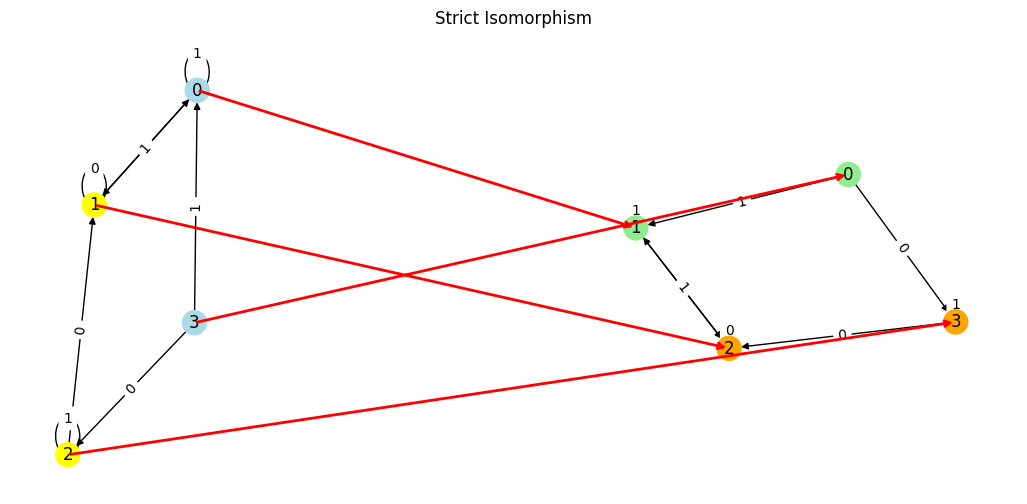

{0: 2, 1: 1, 2: 3, 3: 0}


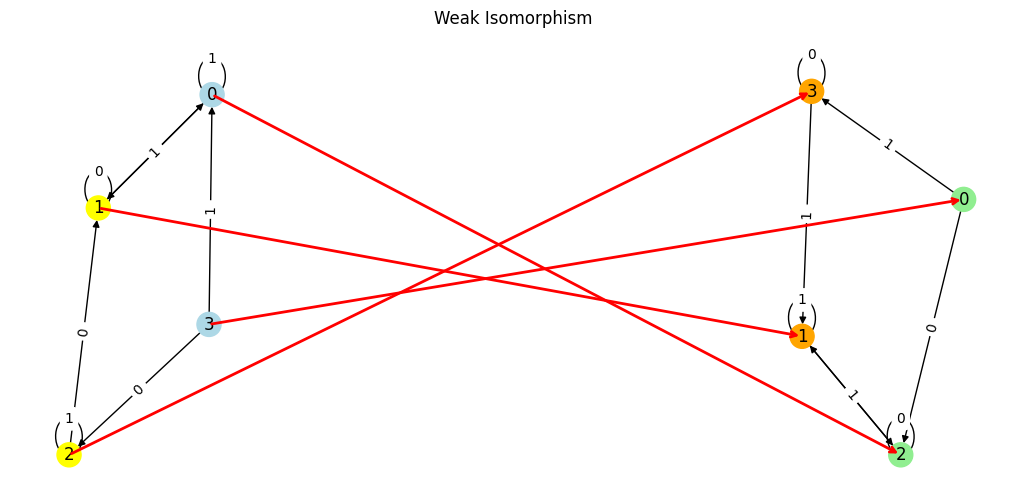

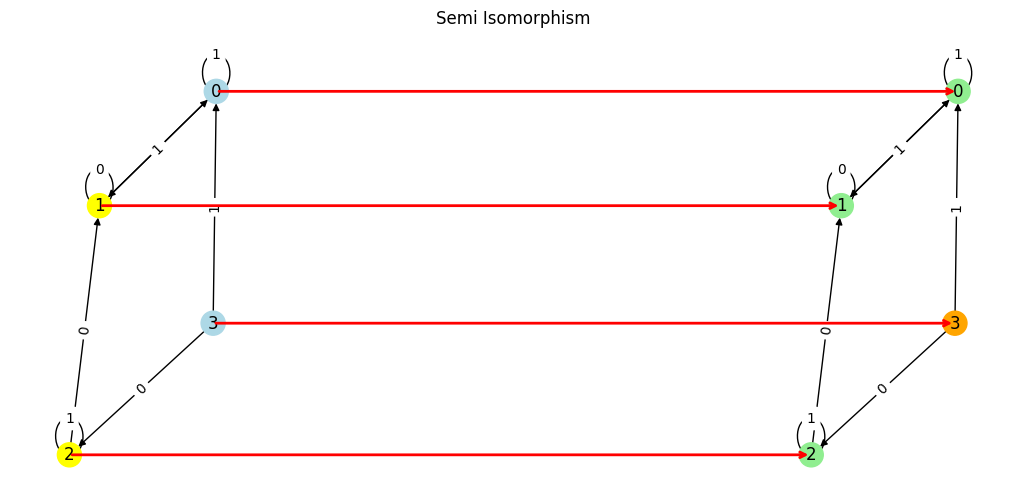

In [30]:
# Visualisation of isomorphism checks (Alex)

def unpack_dfa(A): # seperates the parts of the DFA
    Q, Sigma, delta, q0, F = A
    return Q, Sigma, delta, q0, F


def build_graph(A1):
    Q, Sigma, delta, q0, F = unpack_dfa(A1) # Unpacks parts of DFA
    G=nx.DiGraph()
    for q in Q:
        G.add_node(q,accepting=(q in F),start=(q==q0)) # adds all points in DFA to the graph
    for (state,sym), target in delta.items():
        G.add_edge(state,target,label=str(sym)) # Shows direction of points connections to one another
    return G

def draw_dfas(A,B,mapping=None, Title="DFA comparison"):
    
    GA=build_graph(A)
    GB=build_graph(B)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.set_title(Title)

    posA = nx.spring_layout(GA, seed=1)
    for k in posA:
        posA[k] = (posA[k][0] - 2, posA[k][1])

    posB = nx.spring_layout(GB, seed=1)
    for k in posB:
        posB[k] = (posB[k][0] + 2, posB[k][1])
    
    node_colors_A = ["lightblue" if not GA.nodes[n]["accepting"] else "yellow" for n in GA.nodes]
    nx.draw(GA, posA, with_labels=True, node_color=node_colors_A, edge_color="black", ax=ax)
    nx.draw_networkx_edge_labels(GA, posA, edge_labels=nx.get_edge_attributes(GA, "label"), ax=ax)

    # draw DFA B (right)
    node_colors_B = ["lightgreen" if not GB.nodes[n]["accepting"] else "orange" for n in GB.nodes]
    nx.draw(GB, posB, with_labels=True, node_color=node_colors_B, edge_color="black", ax=ax)
    nx.draw_networkx_edge_labels(GB, posB, edge_labels=nx.get_edge_attributes(GB, "label"), ax=ax)

    # draw mapping arrows between DFAs
    if mapping:
        for qa, qb in mapping.items():
            x1, y1 = posA[qa]
            x2, y2 = posB[qb]
            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="red", lw=2)
            )

    plt.axis("off")
    plt.show() # Shows the graphs

def reachable_states(Q, delta, q0, Sigma):
    visited = set()
    stack = [q0]
    while stack:
        s = stack.pop()
        if s not in visited:
            visited.add(s)
            for a in Sigma:
                stack.append(delta[(s, a)])
    return visited


def find_iso_mapping(A, B, mode="strict"):
    QA, SigmaA, deltaA, q0A, FA = unpack_dfa(A) # unpacks DFA's tp be easily used
    QB, SigmaB, deltaB, q0B, FB = unpack_dfa(B)

    if mode == "strict":
        if SigmaA != SigmaB or len(QA) != len(QB) or len(FA) != len(FB):
            return None
        statesA = sorted(QA)
        statesB = sorted(QB)
        letter_perms = [{a: a for a in SigmaA}]  # g is identity for strict

    elif mode == "weak":
        if len(SigmaA) != len(SigmaB):
            return None
        # only compare reachable parts
        RA = reachable_states(QA, deltaA, q0A, SigmaA)
        RB = reachable_states(QB, deltaB, q0B, SigmaB)
        
        if len(RA) != len(RB):
            return None
        
        statesA = sorted(RA)
        statesB = sorted(RB)
        
        FA = FA & RA
        FB = FB & RB
        lA = sorted(SigmaA)
        lB = sorted(SigmaB)
        letter_perms = [dict(zip(lA, perm)) for perm in permutations(lB)]

    elif mode == "semi":
        # allow collapsing A into subset of B
        if len(SigmaA) != len(SigmaB) or len(QA) != len(QB):  # A must be greater than B for merging
            return None
        
        statesA = sorted(QA)
        statesB = sorted(QB)
        
        lA = sorted(SigmaA)
        lB = sorted(SigmaB)
        letter_perms = [dict(zip(lA, perm)) for perm in permutations(lB)]

    for g in letter_perms:
        for perm in permutations(statesB):
            mapping = dict(zip(statesA, perm))

            # start state must be preserved (not for semi)
            if mode != "semi" and mapping.get(q0A) != q0B:
                continue

            # accepting states must be preserved (not for semi)
            if mode in ("strict", "weak"):
                if {mapping[q] for q in FA} != FB:
                    continue

            OK = True # while this is true we return a mapping at the end
            for (s, sym), targetA in deltaA.items(): #for each tuple and point in the 1st DFA
                if s not in mapping or targetA not in mapping:
                    continue
                
                mapped_s = mapping[s]
                mapped_sym = g[sym]  # apply letter bijection g
                if (mapped_s, mapped_sym) not in deltaB:
                    OK = False
                    break
                
                if mapping[targetA] != deltaB[(mapped_s, mapped_sym)]:
                    OK = False
                    break
                
            #as long as no issues have been found gives the mapping
            if OK:
                return mapping

    return None




#This defines the two DFA's which fullfill each requirements
A=A1
B=random_strict_isom(A1)

C=random_weak_isom(A1)

D=random_semi_isom(A1)

strict_iso=strict_isom(A,B)
weak_iso=weak_isom(A,C)

semi_iso=semi_isom(A,D)




#Below checks if each is true or false and if true draws mappings between and otherwise just draws the two DFA's
if strict_iso==True:
    mapping = find_iso_mapping(A,B)
    draw_dfas(A, B, mapping, "Strict Isomorphism")
else:
    draw_dfas(A, B, None, "NOT Strict Isomorphic")

if weak_iso==True:
    mapping = find_iso_mapping(A, C,"weak")
    print(mapping)
    draw_dfas(A, C, mapping, "Weak Isomorphism")
else:
    draw_dfas(A, C, None, "NOT Weakly Isomorphic")
if semi_iso==True:
    mapping = find_iso_mapping(A, D,"semi")
    draw_dfas(A, D, mapping, "Semi Isomorphism")
else:
    draw_dfas(A, D, None, "NOT Semi-Isomorphic")

### 2 (d): Does isomporhism preserve synchronisation?


A DFA is synchronising iff there exists a reset word, that is, a word $w$ over the alphabet $\Sigma$ such that no matter what state you start in, reading $w$ always brings you to the same end state.

If we know a DFA, $A_1$, is synchronising and isomporhic to another DFA, $A_2$, does that mean $A_2$ is also synchronising?

Synchronisation depends on the transisition structure of the automaton.  Thererfore, we shall break down the three cases of isomorphism and whether or not their conditions of structure allow for synchronisation.


####Strict isomophism

We can think about strict isomorphisms as simply renaming the states.  That is, strict isomorphisms preserve:

- the state-transition structure
- the alphabet exactly
- the start state
- the accepting states

Because the exact alphabet is unchanged and transitions commute with the state bijection: a word $w$ would send all states of $A_1$ to one single state iff the same word $w$ sends all of states $A_2$ to the one state.

therefore, strict isomorphism preserves synchronising.

an additional point, if 'W' is a synchronising word for A1, then the exact same word is a synchronising word for A2 as the alphabet and transisitions structure are identical.




Weak isomorphism,

here we can rename the states and the alphabet symbols

weak isomporhism preserves,

-the tansistion structure (up to renaming of states and alphabet symbols)
-the same start and final states

so generally, if a word w synchronises A1, then g(w) synchronises A2.

mathematically,

if g : E1 -> E2 is the alphabet bijection, then a word W,

 W = a1, a2, ..., ak

in DFA A1 corresponds to the word,

g(W) = g(a1), g(a2), ..., g(ak)

in DFA A2

so if W synchronises A1, then g(W) synchronises A2.

therefore, weak isomporhism preserves synchronisation.

however, this does not extend to the same strength as strict isomporhism in terms of word W. As we can see, weak isomporhism preserves synchronisation, but the reset word that synchronises each DFA may change.



Semi-isomorphism,

here we preserve only,

-the transistion structure up to renaming the states and letters

we do not need to worry about preserving,

-the start state
-the accepting state

semi-isomporhism generally preserves isomporhism as synchronisation is not concerned about start and final states.

as for all states and letters, then the whole action of a word is preserved under the relabellings f and g.
therefore if a word 'W' collapses all states of A1 to one state, and the corresponding relabelled word g(W) collapses all states of A2 to one state, then semi-isomorphism preserves synchronisation.

The subtlety is that semi-isomporhism preserved synchronisation only as a property of the transistion system itself, not as a property tied to the start or accepting states.


in conclusion, all three notions of isomorphism preserve synchronicity, but to varying degrees.

-all three preserve the existence of a synchronising word
-strict-isomorphism preserves it the strongest, as the exact reset word is unchanged between the DFA's
-weak and semi-isomorphism preserve it up to the relabelling of letters, so may give different reset words between DFA's
-we have found that the start and final state preservation is irrelevant for synchronisation, it does not affect the existence of a synchronising word as seen in the semi-isomophism case.



###Canonicalisation & Minimisation of DFAs
**add text**

###Roles
Rhiannon and Penelope decided to complete the first three isomorphic questions independently and combine their code into one final solution, taking the most efficient parts from either while maintaining readability. Rhiannon’s code had stronger backtracking structure, transition validation, and semi-isomorphic checks, while Penelope's had better alphabet mapping and identified structural violations earlier.

Penelope combined the solutions and found additional ways to opptimize efficenty and revised and rewrote the syntax and comments to create a clear readable format.

Rhiannon created DFAs that were known to be strictly, weakly, semi, and non-isomorphic to the example DFA given in the project specifications, that is, $A_2$, $A_3$, $A_4$, and $A_5$.  Penelope then wrote functions to generate more random DFAs for testing.

Penelope wrote a function which ran $\texttt{strict_isom}$, $\texttt{weak_isom}$, and $\texttt{semi_isom}$ on the known DFAs, measured the runtime, and clearly printed the results.

Rhiannon focused on answering Q2d.

**add originality roles**

Both Rhiannon and Penelope outlined and combined individual teammates thoughts into a final report.  Penelope wrote the sections for Q2, with Rhiannon's input, and the AI usage section while Rhiannon wrote the general introduction and mathematical background.

# AI Usage

**AI was used by Caelan for**

- **Research:** finding existing literature relevant to part 1. Any facts used were checked against their original source.

- **Syntax:** advice on syntax for producing plots for Q1

**AI was used by Alex for**

- **Coding:** on how to define a DFA in python

- **Wording:** advice on how to briefly explain terminology and methods used in Q1a

**AI was used by Megu for**

- **Teaching:** occasionally clarifying terminology used in the lecture notes, including defining the term “image” in the context of transformations of state sets

**AI was used by Alfie for**

- **Code debugging:** Claude was used to help identify and explain errors in the implementation. In all such cases the AI identified the source of the error and explained why it occurred, but the fixes were applied and verified manually.

- **Report sanity-check:** AI was used to review the accuracy of written comments and mathematical claims, including checking runtime complexity arguments

- **Writing assistance:** AI was used to help draft and refine markdown commentary, including the algorithm descriptions and results analysis sections. The content and reasoning in these sections reflects Alfie's own understanding of the code, with AI used to improve clarity and structure rather than to generate technical content independently.


**AI was used by Penelope for**

- **Code comparison:** comparing Penelope and Rhiannon's algorithms for Q2 and asking to identify examples where one version was more efficient than the other.

- **Teaching:** explaining sourse states, strongly connected components, and condensation graphs

**AI was used by Rhiannon for**

- **insert info**

**All code in this submission was written by us. AI was not used to generate any of the function implementations directly.**